# Localised PV Generation Forecasting — weather inputs, learned envelope, calibrated bands

**EnerTEF · TEF-EV (Leneda, Luxembourg)**

The service forecasts the Copal Supermarket energy community. The history-only baseline and its
out-of-sample evaluation (`ECC_PV_Evaluation_Elia.ipynb`) exposed four weaknesses; each is addressed
by one design choice, and each choice is **measured on its own** so it is kept only if the data
supports it.

| Baseline limitation | Design choice | Where |
|---|---|---|
| Day-ahead has no skill beyond persistence (no weather input) | **Numerical-weather-prediction features** from Open-Meteo *Previous Runs* — forecasts as issued 24 h / 48 h before the valid time, with a 6 h availability lag so nothing from the future leaks in | §2, §4 |
| Clear-sky shape is plant-specific; one slope for the whole year | **Learned clear-sky envelope** — a smooth conditional upper quantile of output given sun elevation, azimuth and season — instead of one kW-per-W/m² slope | §3 |
| P10–P90 coverage 67–75 % (nominal 80 %), swings with the season | **Online conformal recalibration** of the band from the most recent out-of-sample forecasts | §6 |
| Selection and metrics rest on one 60-day winter hold-out | **Rolling-origin validation over a full year** (5 expanding-window folds) with a factorial ablation, and a **pickle-free export** | §5–§8 |

Everything is evaluated against 24 h persistence and the previous release's hold-out numbers (§11).

## Protocol — fixed before any result was looked at

| | |
|---|---|
| Folds | five expanding-window test folds covering 1 Jan 2025 → 18 Jan 2026 (winter, spring, summer, early autumn, and the previous release's winter hold-out). For each, the models are trained on data older than 60 days before the fold, the 60 days in between calibrate the band, and the fold itself is scored |
| Leakage rules | history strictly before the issue time, plus: training rows whose *target* lies beyond the training cut-off are purged; weather forecasts count as available 6 h after their nominal run; the envelope is refitted inside each fold on training data only; conformal scores use only outcomes already observed at the issue time |
| Configurations | `base` (history-only features and slope envelope, LightGBM) · `+weather` · `+envelope` · `+weather +envelope`, then conformal bands on top of the best |
| Scoring | daytime 15-minute slots, identical slot set for every configuration; P50 MAE and skill against 24 h persistence; P10–P90 coverage, width and interval score; pooled over folds and per fold |
| Adoption rules | **weather** — adopt if the day-ahead P50 MAE falls by ≥ 3 % pooled and a paired day-block bootstrap puts the whole 90 % interval below zero, without hurting intraday. **envelope** — assessed with the adopted weather features in place (`+weather +envelope` against `+weather`): adopt if the pooled MAE does not rise in either block (the 90 % bootstrap interval is not entirely above zero) **and** it reduces the *transfer bias* on the Elia series by ≥ 30 %, where transfer bias = the mean over the test months and both blocks of the absolute monthly P50 bias, in % of capacity (the 2 × 2 also shows the contrast without weather). *Wording clarified after the first look at the validation table, which showed the envelope's effect differs with and without weather; the Elia criterion had not been run.* **conformal** — adopt if mean \|coverage − 80 %\| and the interval score both fall |
| External check | the final configuration, trained on Copal only, is scored on the Elia Luxembourg-province series (Copal-equivalent kW, envelope refitted) over 19 Nov 2025 → 30 Sep 2026, against Elia's own 6 PM day-ahead forecast |

Weather data: Open-Meteo Previous Runs API (CC BY 4.0; the free tier is for non-commercial use only — a
production service needs a subscription). Elia data: Elia Open Data (ODS032).


## 1 · Setup

Plant and method constants, and the validation windows, are fixed here for reproducibility.


In [1]:
import json
import time
import warnings
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path
from urllib.error import HTTPError
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", message="X does not have valid feature names")

ROOT = Path.cwd()
DATA_CSV = ROOT / "Data" / "ECC_master_PV_EMOB1_EMOB2_15min.csv"
CACHE_DIR = ROOT / "Data" / "external"
MODEL_DIR = ROOT / "Data" / "models"
for path in (DATA_CSV,):
    if not path.is_file():
        raise FileNotFoundError(f"{path} not found — start Jupyter from the repository root.")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Plant and method constants
PLANT_ID = "copal-ecc"
CAPACITY_KWC = 973.81
LATITUDE, LONGITUDE = 49.70673, 6.48714
SLOT = pd.Timedelta(minutes=15)
KCS_MAX = 1.3                    # clear-sky index cap
NIGHT_GHI_WM2 = 10.0             # below this clear-sky GHI a slot counts as night
ENVELOPE_MIN_GHI_WM2 = 200.0     # slope envelope: well-lit slots used for the fit
ENVELOPE_QUANTILE = 0.995        # slope envelope: slope = this quantile of PV / clear-sky GHI
ENV_FLOOR_KW = 0.005 * CAPACITY_KWC   # below this clear-sky power a slot is "dawn/dusk": no clear-sky index
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}
MISSING = -1.0
GITHUB_REPO = "https://github.com/ENERTEF/TEF-EV-Service-2----Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities-"
HF_REPO = "EnerTEF/EV-Service2-Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities"      # see the publish section at the end

# Method settings
CAL_DAYS = 60                    # out-of-sample days between model fit and test fold (band calibration)
CONFORMAL_WINDOW_DAYS = 45       # trailing window of observed outcomes used to recalibrate the band
CONFORMAL_MIN_N = 300            # fewer scores than this in a bucket → no adjustment
NWP_LAG_H = 6.0                  # a weather run is usable 6 h after its nominal initialisation
LEARNED_ENV_QUANTILE = 0.98
BLOCKS = {
    "intraday": {"leads_h": (0.0, 6.0), "issue_hours_utc": [4, 6, 8, 10, 12, 14, 16, 18]},
    "day_ahead": {"leads_h": (6.0, 24.0), "issue_hours_utc": [0, 6, 12, 18]},
}
LEAD_BUCKETS = {"intraday": [0.0, 1.0, 3.0, 6.0], "day_ahead": [6.0, 12.0, 18.0, 24.0]}  # conformal calibration groups

# Series bounds and the training cut-off — fixed for reproducibility
COPAL_FIRST = pd.Timestamp("2023-10-11 22:00", tz="UTC")
TRAIN_END = pd.Timestamp("2025-11-19 22:45", tz="UTC")     # training cut-off
COPAL_LAST = pd.Timestamp("2026-01-18 22:45", tz="UTC")    # last Copal observation
ELIA_END = pd.Timestamp("2026-10-01 00:00", tz="UTC")     # exclusive; pinned for reproducibility
NWP_START, NWP_END = pd.Timestamp("2024-01-01", tz="UTC"), ELIA_END

FOLD_EDGES = [pd.Timestamp(d, tz="UTC") for d in ("2025-01-01", "2025-04-01", "2025-07-01", "2025-10-01")] + [TRAIN_END, COPAL_LAST]
FOLDS = [
    {"name": name, "test_start": a, "test_end": b, "train_end": a - pd.Timedelta(days=CAL_DAYS)}
    for name, (a, b) in zip(("winter 2025 (Jan–Mar)", "spring 2025 (Apr–Jun)", "summer 2025 (Jul–Sep)",
                             "autumn 2025 (Oct–19 Nov)", "winter hold-out (19 Nov–18 Jan)"),
                            zip(FOLD_EDGES[:-1], FOLD_EDGES[1:]))
]
print(f"LightGBM {version('lightgbm')} · numpy {version('numpy')} · pandas {version('pandas')}")
display(pd.DataFrame([{"fold": f["name"], "trained on data before": f["train_end"], "band calibrated on": f"{CAL_DAYS} days up to",
                       "test from": f["test_start"], "test to": f["test_end"]} for f in FOLDS]))

LightGBM 4.7.0 · numpy 2.4.6 · pandas 3.0.6


,fold,trained on data before,band calibrated on,test from,test to
0,winter 2025 (Jan–Mar),2024-11-02 00:00:00+00:00,60 days up to,2025-01-01 00:00:00+00:00,2025-04-01 00:00:00+00:00
1,spring 2025 (Apr–Jun),2025-01-31 00:00:00+00:00,60 days up to,2025-04-01 00:00:00+00:00,2025-07-01 00:00:00+00:00
2,summer 2025 (Jul–Sep),2025-05-02 00:00:00+00:00,60 days up to,2025-07-01 00:00:00+00:00,2025-10-01 00:00:00+00:00
3,autumn 2025 (Oct–19 Nov),2025-08-02 00:00:00+00:00,60 days up to,2025-10-01 00:00:00+00:00,2025-11-19 22:45:00+00:00
4,winter hold-out (19 Nov–18 Jan),2025-09-20 22:45:00+00:00,60 days up to,2025-11-19 22:45:00+00:00,2026-01-18 22:45:00+00:00


## 2 · Data

**Copal** — the Leneda 15-minute series (UTC, clipped to 0…nameplate).

**Weather** — Open-Meteo *Previous Runs API*, location of the plant, hourly, UTC. A value tagged `d1` is what a
model **predicted 24 h before the valid hour**, `d2` 48 h before (the API's fixed lead-time offsets, independent
of the run that produced them). That is exactly the information a day-ahead forecaster has, unlike the
*Historical Forecast* archive, which stitches together the first hours of every run and would let near-analysis
values leak into a "forecast". The archive starts in January 2024, so earlier Copal days have no weather
(`has_weather = 0`, the reserved missing value `-1`).

* **ICON-EU** supplies the full set — GHI, DNI, DHI, cloud cover, temperature, wind. Of the single models its
  forecast clear-sky index agrees best with Copal's output (correlation and mean error in the table at the end of §4).
* **ECMWF IFS and ARPEGE** supply GHI only; the mean clear-sky index of the three models is one extra feature
  (it has the highest correlation with Copal's output of all, same table).

**Elia** — the Luxembourg-province series of the evaluation notebook, used only for the external check in §9
(downloaded to the same cache file if the evaluation notebook has not already done it).

In [2]:
# ---- Copal --------------------------------------------------------------------------------
raw = pd.read_csv(DATA_CSV, usecols=["Started at", "PV_TotalProduction_kW"])
ts_utc = pd.to_datetime(raw["Started at"], utc=True, errors="coerce", format="ISO8601")
copal_pv = pd.Series(pd.to_numeric(raw["PV_TotalProduction_kW"], errors="coerce").to_numpy(),
                     index=pd.DatetimeIndex(ts_utc, name="ts_utc"), name="pv_kw")
copal_pv = copal_pv[copal_pv.index.notna()].sort_index().clip(0.0, CAPACITY_KWC)
print(f"Copal: {copal_pv.dropna().index[0]:%d %b %Y} → {copal_pv.dropna().index[-1]:%d %b %Y}, "
      f"{copal_pv.notna().sum():,} usable 15-min intervals, peak {copal_pv.max():.0f} kW")

# ---- Open-Meteo Previous Runs ----------------------------------------------------------------------
OM_URL = "https://previous-runs-api.open-meteo.com/v1/forecast"
NWP_LEADS = (1, 2)                                        # previous_day1 / previous_day2
NWP_MODELS = {
    "icon_eu": {"shortwave_radiation": "ghi", "direct_normal_irradiance": "dni", "diffuse_radiation": "dhi",
                "cloud_cover": "cloud", "temperature_2m": "temp", "wind_speed_10m": "wind"},
    "ecmwf_ifs025": {"shortwave_radiation": "ghi"},
    "meteofrance_arpege_europe": {"shortwave_radiation": "ghi"},
}


def fetch_nwp(model: str, variables: dict, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # Quarter-by-quarter requests, retried: the free API occasionally drops the connection.
    frames = []
    a = start
    while a < end:
        b = min(a + pd.DateOffset(months=3), end)          # exclusive
        query = urlencode({
            "latitude": LATITUDE, "longitude": LONGITUDE, "models": model, "timezone": "GMT", "wind_speed_unit": "ms",
            "start_date": f"{a:%Y-%m-%d}", "end_date": f"{b - pd.Timedelta(days=1):%Y-%m-%d}",
            "hourly": ",".join(f"{v}_previous_day{k}" for v in variables for k in NWP_LEADS),
        })
        for attempt in range(5):
            try:
                with urlopen(Request(f"{OM_URL}?{query}", headers={"User-Agent": "enertef-pv-forecasting"}), timeout=180) as resp:
                    payload = json.load(resp)
                break
            except HTTPError as exc:
                raise RuntimeError(f"Open-Meteo refused {model} {a:%Y-%m-%d}: {exc.read()[:200]!r}") from exc
            except OSError:
                time.sleep(5 * (attempt + 1))
        else:
            raise RuntimeError(f"Open-Meteo unreachable for {model} {a:%Y-%m-%d}")
        h = pd.DataFrame(payload["hourly"])
        h.index = pd.DatetimeIndex(pd.to_datetime(h.pop("time"))).tz_localize("UTC")
        frames.append(h.rename(columns={f"{v}_previous_day{k}": f"{model}|{name}|d{k}"
                                        for v, name in variables.items() for k in NWP_LEADS}))
        a = b
        time.sleep(0.4)
    return pd.concat(frames).sort_index()


nwp_cache = CACHE_DIR / f"openmeteo_previous_runs_{LATITUDE:.3f}_{LONGITUDE:.3f}_{NWP_START:%Y%m%d}_{NWP_END:%Y%m%d}.csv"
if not nwp_cache.is_file():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    nwp = pd.concat([fetch_nwp(m, v, NWP_START, NWP_END) for m, v in NWP_MODELS.items()], axis=1)
    nwp.to_csv(nwp_cache.with_suffix(".part"))
    nwp_cache.with_suffix(".part").replace(nwp_cache)
    print(f"downloaded Open-Meteo previous runs → {nwp_cache.relative_to(ROOT).as_posix()}")
else:
    print(f"using cached {nwp_cache.relative_to(ROOT).as_posix()}")
nwp = pd.read_csv(nwp_cache, index_col=0, parse_dates=True)
nwp.index = pd.DatetimeIndex(nwp.index, tz="UTC") if nwp.index.tz is None else nwp.index

ghi_cols = [c for c in nwp.columns if "|ghi|" in c]
display(pd.DataFrame({
    "first valid hour": pd.Series({c: nwp[c].first_valid_index() for c in ghi_cols}),
    "non-null since 1 Feb 2024 (%)": (100 * nwp.loc["2024-02-01":, ghi_cols].notna().mean()).round(1),
}))
print(f"weather table: {nwp.shape[0]:,} hours × {nwp.shape[1]} columns, "
      f"{nwp.index[0]:%d %b %Y} → {nwp.index[-1]:%d %b %Y %H:%M} UTC; non-null since Feb 2024: "
      f"{100 * nwp.loc['2024-02-01':].notna().mean().min():.1f} % in the worst column")

Copal: 11 Oct 2023 → 18 Jan 2026, 79,684 usable 15-min intervals, peak 751 kW
using cached Data/external/openmeteo_previous_runs_49.707_6.487_20240101_20261001.csv


,first valid hour,non-null since 1 Feb 2024 (%)
icon_eu|ghi|d1,2024-01-19 12:00:00+00:00,100.0
icon_eu|ghi|d2,2024-01-20 12:00:00+00:00,99.6
ecmwf_ifs025|ghi|d1,2024-03-06 17:00:00+00:00,96.4
ecmwf_ifs025|ghi|d2,2024-03-07 17:00:00+00:00,96.3
meteofrance_arpege_europe|ghi|d1,2024-01-19 12:00:00+00:00,100.0
meteofrance_arpege_europe|ghi|d2,2024-01-20 12:00:00+00:00,99.7


weather table: 24,096 hours × 16 columns, 01 Jan 2024 → 30 Sep 2026 23:00 UTC; non-null since Feb 2024: 96.3 % in the worst column


## 3 · Clear-sky reference and the plant envelope — slope vs learned

The physics is standard (NOAA solar position, Ineichen–Perez clear sky, Linke turbidity 3.0, slot midpoints), plus
the solar **azimuth**, which the learned envelope needs.

The models predict the **clear-sky index** — measured PV ÷ the power the plant would deliver under a clear sky —
so the quality of that denominator is the quality of the target. The history-only baseline takes it as a single slope times clear-sky
GHI (0.798 kW per W/m², capped at 662 kW). The evaluation notebook showed that this is plant-specific: Copal's
output per W/m² *rises* with sun height while a fleet of tilted roofs *falls*, so one slope gives a clear-sky
index that is 0.63 on a clear winter morning and 0.92 on a clear summer noon — structure the model must then
learn on top of the weather.

**Learned envelope.** The clear-sky power as a smooth function of where the sun is: a LightGBM **98th-percentile
regressor** of output on sun elevation, azimuth and season (sin / cos of the day of year), few shallow trees and
large leaves so it stays smooth. It needs no tilt, azimuth or capacity of the plant, only its history, and it is
refitted for any new site.

In [3]:
def solar_geometry(times: pd.DatetimeIndex) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # NOAA solar zenith (degrees), extraterrestrial normal irradiance (W/m²) and azimuth (degrees from north,
    # clockwise) at UTC `times`. Zenith and irradiance use the standard NOAA formulas.
    year_start = pd.to_datetime(times.year.astype(str) + "-01-01", utc=True)
    doy = np.asarray((times - year_start).total_seconds() / 86400.0)  # fractional, 0-based
    year_len = np.where(times.is_leap_year, 366.0, 365.0)
    g = 2.0 * np.pi / year_len * doy
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    minutes = np.asarray(times.hour * 60.0 + times.minute + times.second / 60.0)
    hour_angle = np.radians(((minutes + (eqtime + 4.0 * LONGITUDE)) % 1440.0) / 4.0 - 180.0)
    lat = np.radians(LATITUDE)
    cos_z = np.clip(np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(hour_angle), -1.0, 1.0)
    zenith = np.degrees(np.arccos(cos_z))
    dni_extra = 1361.0 * (1.0 + 0.033 * np.cos(2.0 * np.pi * doy / year_len))
    azimuth = np.degrees(np.arctan2(np.sin(hour_angle), np.cos(hour_angle) * np.sin(lat) - np.tan(decl) * np.cos(lat))) + 180.0
    return zenith, dni_extra, azimuth


def slot_geometry(index: pd.DatetimeIndex) -> pd.DataFrame:
    # Geometry and Ineichen–Perez clear-sky GHI at the midpoint of each interval starting at `index`.
    mid = index + SLOT / 2
    zenith, dni_extra, azimuth = solar_geometry(mid)
    cos_z = np.cos(np.radians(zenith))
    up = zenith < 90.0
    z = np.where(up, zenith, 0.0)
    airmass = 1.0 / (np.cos(np.radians(z)) + 0.50572 * (96.07995 - z) ** -1.6364)  # Kasten–Young
    ghi = 0.868 * dni_extra * np.maximum(cos_z, 1e-6) * np.exp(-0.0387 * airmass * 3.0)  # Linke turbidity 3.0
    doy = 2 * np.pi * (mid.dayofyear.to_numpy() - 1) / 365.25
    return pd.DataFrame({"cs_ghi": np.where(up, np.maximum(ghi, 0.0), 0.0), "cos_z": cos_z, "elevation": 90.0 - zenith,
                         "azimuth": azimuth, "doy_sin": np.sin(doy), "doy_cos": np.cos(doy)}, index=index)


# One geometry table for everything: Copal's whole file range plus the Elia period and one day of look-ahead.
GEO = slot_geometry(pd.date_range(copal_pv.index[0], ELIA_END + pd.Timedelta(days=1), freq=SLOT))

ENV_FEATURES = ["elevation", "azimuth", "doy_sin", "doy_cos"]


def fit_slope_envelope(pv: pd.Series, until: pd.Timestamp) -> dict:
    # kW per W/m² of clear-sky GHI (99.5th percentile over well-lit slots) and a cap (99.9th percentile of output).
    u = pv.dropna()
    u = u[u.index < until]
    cs = GEO.cs_ghi.reindex(u.index)
    lit = cs >= ENVELOPE_MIN_GHI_WM2
    slope = min(float(np.quantile((u[lit] / cs[lit]).to_numpy(), ENVELOPE_QUANTILE)), CAPACITY_KWC / 1000)
    return {"type": "slope", "kw_per_wm2": round(slope, 6), "max_kw": round(min(float(np.quantile(u.to_numpy(), 0.999)), CAPACITY_KWC), 3)}


def fit_learned_envelope(pv: pd.Series, until: pd.Timestamp, quantile: float = LEARNED_ENV_QUANTILE) -> dict:
    # Smooth conditional upper quantile of output given sun elevation, azimuth and season.
    u = pv.dropna()
    u = u[u.index < until]
    g = GEO.reindex(u.index)
    day = (g.cs_ghi >= NIGHT_GHI_WM2).to_numpy()
    model = lgb.LGBMRegressor(objective="quantile", alpha=quantile, n_estimators=200, max_depth=4, num_leaves=15,
                              learning_rate=0.05, min_child_samples=100, subsample=0.8, subsample_freq=1,
                              random_state=42, verbose=-1)
    model.fit(g.loc[day, ENV_FEATURES], u[day])
    return {"type": "learned", "model": model, "quantile": quantile, "features": ENV_FEATURES,
            "max_kw": round(min(float(np.quantile(u.to_numpy(), 0.999)), CAPACITY_KWC), 3)}


def fit_envelope(kind: str, pv: pd.Series, until: pd.Timestamp) -> dict:
    return fit_slope_envelope(pv, until) if kind == "slope" else fit_learned_envelope(pv, until)


def envelope_kw(env: dict, geo: pd.DataFrame) -> pd.Series:
    # Clear-sky power (kW) of the plant for the geometry rows `geo`.
    if env["type"] == "slope":
        kw = env["kw_per_wm2"] * geo.cs_ghi
    else:
        kw = pd.Series(env["model"].predict(geo[env.get("features", ENV_FEATURES)]), index=geo.index)
    return kw.clip(0.0, env["max_kw"]).where(geo.cs_ghi >= NIGHT_GHI_WM2, 0.0)


def make_grid(pv: pd.Series, env: dict) -> pd.DataFrame:
    # One row per 15-min slot, from the first observation to one day past the last (the longest lead).
    idx = pd.date_range(pv.index[0], pv.index[-1] + pd.Timedelta(days=1), freq=SLOT)
    geo = GEO.reindex(idx)
    grid = geo[["cs_ghi", "cos_z"]].copy()
    grid["pv"] = pv.dropna().reindex(idx)
    grid["cs_kw"] = envelope_kw(env, geo)
    ok = (grid.cs_ghi >= NIGHT_GHI_WM2) & (grid.cs_kw >= ENV_FLOOR_KW)
    grid["kcs"] = (grid.pv / grid.cs_kw.where(ok)).clip(0.0, KCS_MAX).where(ok & grid.pv.notna())
    return grid


# Sanity: the refit slope envelope reproduces the shipped one
SHIPPED_SLOPE = {"type": "slope", "kw_per_wm2": 0.799626, "max_kw": 662.723}
check = fit_slope_envelope(copal_pv, COPAL_LAST)
print(f"slope envelope refit on all Copal data: {check['kw_per_wm2']} kW per W/m², cap {check['max_kw']} kW "
      f"(shipped {SHIPPED_SLOPE['kw_per_wm2']} / {SHIPPED_SLOPE['max_kw']})")

slope envelope refit on all Copal data: 0.798429 kW per W/m², cap 661.8 kW (shipped 0.799626 / 662.723)

## 4 · Features and samples — only what is known at issue time

A forecast is issued at `t₀` and predicts every daylight 15-minute slot of its
horizon (intraday 0–6 h every 2 h from 04 to 18 UTC; day-ahead 6–24 h at 00 / 06 / 12 / 18 UTC), with
history lookups strictly before `t₀`:

* **Weather features** (24 features). For a target slot `T` the
  forecast used is the one issued **24 h before `T`** (`d1`) when that run is already usable at `t₀`
  — i.e. when the lead `T − t₀` is at most 24 h − 6 h = 18 h — and the one issued **48 h before** (`d2`)
  otherwise. Radiation is the mean of the preceding hour (the API's convention), so a slot takes the value of the
  hour that contains it; cloud cover, temperature and wind are instantaneous and are interpolated to the slot
  midpoint. `kcs_fc` is the forecast clear-sky index of ICON-EU's GHI (hour-mean forecast ÷ hour-mean clear-sky
  GHI), `kcs_fc_ens` the mean over ICON-EU, ECMWF IFS and ARPEGE, and `nwp_lead_d` records whether `d1` or `d2`
  was used. If the chosen forecast is missing the older one is used; if both are, the columns are `-1` and
  `has_weather = 0`.
* **Purged training rows.** Every row whose *target* lies beyond the cut-off is dropped, not only those whose
  *issue* does.
* **A common slot set.** Every configuration is scored on the same slots: daylight (clear-sky GHI ≥ 10 W/m²), with
  an observation and with an observed value 24 h earlier (the persistence reference, taken straight from the
  series so it does not depend on the envelope). Dawn and dusk slots where the plant's clear-sky power is below
  0.5 % of nameplate carry no clear-sky index: they are not used for training or calibration but are scored.

In [4]:
def nwp_slot_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    # Hourly weather → 15-min slots, for each lead offset k (d1 / d2). Radiation = mean of the preceding hour, so a
    # slot takes the hour that contains it; instantaneous variables are interpolated to the slot midpoint.
    label = index.floor("h") + pd.Timedelta(hours=1)
    mid = index + SLOT / 2
    h0 = mid.floor("h")
    w = ((mid - h0) / pd.Timedelta(hours=1)).to_numpy()
    cs_hour = GEO.cs_ghi.groupby(GEO.index.floor("h") + pd.Timedelta(hours=1)).mean().reindex(label).to_numpy()
    out = {}
    for k in NWP_LEADS:
        for var in ("ghi", "dni", "dhi"):
            out[f"{var}_k{k}"] = nwp[f"icon_eu|{var}|d{k}"].reindex(label).to_numpy()
        for var in ("cloud", "temp", "wind"):
            s = nwp[f"icon_eu|{var}|d{k}"]
            out[f"{var}_k{k}"] = (1 - w) * s.reindex(h0).to_numpy() + w * s.reindex(h0 + pd.Timedelta(hours=1)).to_numpy()
        for tag, model in (("icon", "icon_eu"), ("ecmwf", "ecmwf_ifs025"), ("arpege", "meteofrance_arpege_europe")):
            ghi = nwp[f"{model}|ghi|d{k}"].reindex(label).to_numpy()
            out[f"kcs_{tag}_k{k}"] = np.where(cs_hour >= NIGHT_GHI_WM2, np.clip(ghi / np.maximum(cs_hour, 1e-6), 0.0, 1.5), np.nan)
        stack = np.vstack([out[f"kcs_{t}_k{k}"] for t in ("icon", "ecmwf", "arpege")])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            out[f"kcs_ens_k{k}"] = np.where((~np.isnan(stack)).sum(axis=0) >= 2, np.nanmean(stack, axis=0), np.nan)
    return pd.DataFrame(out, index=index)


FEATURES_BASE = ["clear_sky_kw", "clear_sky_ghi_wm2", "cos_zenith", "tod_sin", "tod_cos", "doy_sin", "doy_cos",
                 "lead_time_hours", "has_recent", "kcs_recent", "pv_last_kw", "kcs_last", "pv_lag_24h_kw", "kcs_lag_24h"]
FEATURES_NWP = FEATURES_BASE + ["has_weather", "ghi_fc_wm2", "dni_fc_wm2", "dhi_fc_wm2", "cloud_fc_pct", "temp_fc_c",
                                "wind_fc_ms", "kcs_fc", "kcs_fc_ens", "nwp_lead_d"]
NWP_SOURCES = {"ghi_fc_wm2": "ghi", "dni_fc_wm2": "dni", "dhi_fc_wm2": "dhi", "cloud_fc_pct": "cloud",
               "temp_fc_c": "temp", "wind_fc_ms": "wind", "kcs_fc": "kcs_icon", "kcs_fc_ens": "kcs_ens"}


def issue_times(block: str, start: pd.Timestamp, end: pd.Timestamp, first: pd.Timestamp) -> pd.DatetimeIndex:
    # Issue schedule of `block` with start <= issue < end (issues without any prior history are dropped).
    days = pd.date_range(start.floor("D"), end, freq="D")
    issues = pd.DatetimeIndex(sorted(d + pd.Timedelta(hours=h) for d in days for h in BLOCKS[block]["issue_hours_utc"]))
    return issues[(issues >= start) & (issues < end) & (issues > first)]


def issue_context(block: str, issues: pd.DatetimeIndex, grid: pd.DataFrame) -> pd.DataFrame:
    # Issue-time features: recent clear-sky index and the last observation (intraday only).
    ctx = pd.DataFrame(index=issues)
    if block == "intraday":
        ctx["kcs_recent"] = grid.kcs.rolling("3h", closed="left").mean().reindex(issues).to_numpy()
        prev1 = grid.pv.reindex(issues - SLOT).to_numpy()
        prev2 = grid.pv.reindex(issues - 2 * SLOT).to_numpy()
        kcs1 = grid.kcs.reindex(issues - SLOT).to_numpy()
        kcs2 = grid.kcs.reindex(issues - 2 * SLOT).to_numpy()
        # the last observation counts only if it is at most 30 min before the issue time
        ctx["pv_last_kw"] = np.where(~np.isnan(prev1), prev1, prev2)
        ctx["kcs_last"] = np.where(~np.isnan(prev1), kcs1, np.where(~np.isnan(prev2), kcs2, np.nan))
    else:
        daily_kcs = grid.kcs.groupby(grid.index.floor("D")).mean()
        ctx["kcs_recent"] = daily_kcs.reindex(issues.floor("D") - pd.Timedelta(days=1)).to_numpy()
        ctx["pv_last_kw"] = np.nan
        ctx["kcs_last"] = np.nan
    return ctx


def build_samples(block: str, start: pd.Timestamp, end: pd.Timestamp, grid: pd.DataFrame, slots: pd.DataFrame) -> pd.DataFrame:
    # Feature rows, targets and baselines for every scored slot of every issue in [start, end).
    issues = issue_times(block, start, end, grid.pv.first_valid_index())
    ctx = issue_context(block, issues, grid)
    lo, hi = (int(h * 4) for h in BLOCKS[block]["leads_h"])
    leads = np.arange(lo, hi)
    issue_ns = np.repeat(issues.as_unit("ns").asi8, len(leads))     # .asi8 follows the index unit, so force ns
    k = np.tile(leads, len(issues))
    ts = pd.DatetimeIndex(pd.to_datetime(issue_ns + k * SLOT.value, unit="ns", utc=True))
    issue = pd.DatetimeIndex(pd.to_datetime(issue_ns, unit="ns", utc=True))

    at = grid.reindex(ts)
    lag_ts = ts - pd.Timedelta(hours=24)
    lag = grid.reindex(lag_ts)
    keep = at.pv.notna().to_numpy() & (at.cs_ghi >= NIGHT_GHI_WM2).to_numpy() & lag.pv.notna().to_numpy()
    ts, issue, k, at, lag, lag_ts = ts[keep], issue[keep], k[keep], at[keep], lag[keep], lag_ts[keep]

    pv_lag = np.where(lag_ts < issue, lag.pv.to_numpy(), np.nan)          # always available: lead < 24 h
    kcs_lag = np.where(np.isnan(pv_lag), np.nan, lag.kcs.to_numpy())
    c = ctx.reindex(issue)
    lead_h = k * 0.25

    # weather: d1 when its run is usable at the issue time, else d2; fall back to d2 if d1 is missing
    nw = slots.reindex(ts)
    want_d1 = lead_h <= 24.0 - NWP_LAG_H
    have_d1 = ~np.isnan(nw["ghi_k1"].to_numpy()) & ~np.isnan(nw["cloud_k1"].to_numpy())
    have_d2 = ~np.isnan(nw["ghi_k2"].to_numpy()) & ~np.isnan(nw["cloud_k2"].to_numpy())
    use_d1 = want_d1 & have_d1
    has_w = use_d1 | have_d2

    def pick(name: str) -> np.ndarray:
        v = np.where(use_d1, nw[f"{name}_k1"].to_numpy(), nw[f"{name}_k2"].to_numpy())
        return np.where(has_w & ~np.isnan(v), v, MISSING)

    minutes = ts.hour * 60 + ts.minute
    tod = 2 * np.pi * minutes / 1440.0
    doy = 2 * np.pi * (ts.dayofyear - 1) / 365.25
    f = pd.DataFrame(
        {
            "clear_sky_kw": at.cs_kw.to_numpy(),
            "clear_sky_ghi_wm2": at.cs_ghi.to_numpy(),
            "cos_zenith": np.maximum(at.cos_z.to_numpy(), 0.0),
            "tod_sin": np.sin(tod), "tod_cos": np.cos(tod),
            "doy_sin": np.sin(doy), "doy_cos": np.cos(doy),
            "lead_time_hours": lead_h,
            "has_recent": c.kcs_recent.notna().astype(float).to_numpy(),
            "kcs_recent": c.kcs_recent.fillna(MISSING).to_numpy(),
            "pv_last_kw": c.pv_last_kw.fillna(MISSING).to_numpy(),
            "kcs_last": c.kcs_last.fillna(MISSING).to_numpy(),
            "pv_lag_24h_kw": np.nan_to_num(pv_lag, nan=MISSING),
            "kcs_lag_24h": np.nan_to_num(kcs_lag, nan=MISSING),
            "has_weather": has_w.astype(float),
            **{feat: pick(src) for feat, src in NWP_SOURCES.items()},
            "nwp_lead_d": np.where(has_w, np.where(use_d1, 1.0, 2.0), MISSING),
        }
    )
    trainable = (at.cs_kw >= ENV_FLOOR_KW).to_numpy()
    f["target_kcs"] = np.where(trainable, np.clip(at.pv.to_numpy() / np.maximum(at.cs_kw.to_numpy(), 1e-9), 0.0, KCS_MAX), np.nan)
    f["actual_kw"] = at.pv.to_numpy()
    f["pers_kw"] = pv_lag
    f["issue"] = issue
    f["ts"] = ts
    return f


# ---- check on one fold: both envelope kinds, weather slots, builder timing ------------------------------
t0 = time.time()
demo_until = FOLDS[0]["train_end"]
demo_env = {kind: fit_envelope(kind, copal_pv, demo_until) for kind in ("slope", "learned")}
print(f"envelopes fitted on data before {demo_until:%d %b %Y} in {time.time() - t0:.1f}s: "
      f"slope {demo_env['slope']['kw_per_wm2']} kW per W/m² (cap {demo_env['slope']['max_kw']} kW)")
NWP_SLOTS_COPAL = nwp_slot_features(pd.date_range(copal_pv.index[0], copal_pv.index[-1] + pd.Timedelta(days=1), freq=SLOT))
t0 = time.time()
demo_grid = make_grid(copal_pv, demo_env["learned"])
demo = build_samples("day_ahead", FOLDS[0]["test_start"], FOLDS[0]["test_end"], demo_grid, NWP_SLOTS_COPAL)
print(f"built {len(demo):,} day-ahead rows for fold 1 in {time.time() - t0:.1f}s; has_weather {demo.has_weather.mean():.3f}, "
      f"d1 share {np.mean(demo.nwp_lead_d == 1.0):.3f}, trainable {demo.target_kcs.notna().mean():.3f}")

envelopes fitted on data before 02 Nov 2024 in 0.2s: slope 0.789217 kW per W/m² (cap 645.0 kW)


built 10,139 day-ahead rows for fold 1 in 0.2s; has_weather 1.000, d1 share 0.676, trainable 1.000


In [5]:
# Does the weather carry signal? The clear-sky index each model forecast, against Copal's observed clear-sky index
# (the shipped slope envelope; 15-min slots with clear-sky GHI ≥ 50 W/m², 1 Feb 2024 → 18 Jan 2026). A diagnostic
# only — nothing is fitted here.
slope_grid = make_grid(copal_pv, SHIPPED_SLOPE)
obs_k = slope_grid.kcs.loc[pd.Timestamp("2024-02-01", tz="UTC"):COPAL_LAST]
sl = NWP_SLOTS_COPAL.reindex(obs_k.index)
lit = (GEO.cs_ghi.reindex(obs_k.index) >= 50).to_numpy() & obs_k.notna().to_numpy()
signal = {}
for lead in NWP_LEADS:
    for tag, label in (("icon", "ICON-EU"), ("ecmwf", "ECMWF IFS"), ("arpege", "ARPEGE"), ("ens", "mean of the three")):
        f = sl[f"kcs_{tag}_k{lead}"].to_numpy()
        ok = lit & ~np.isnan(f)
        signal[(f"issued {24 * lead} h before", label)] = {
            "slots": int(ok.sum()), "correlation": float(np.corrcoef(f[ok], obs_k.to_numpy()[ok])[0, 1]),
            "MAE of the index": float(np.mean(np.abs(f[ok] - obs_k.to_numpy()[ok])))}
signal_df = pd.DataFrame(signal).T.astype({"slots": int}).round(3)
signal_df.index = pd.MultiIndex.from_tuples(signal_df.index, names=["forecast", "model"])
display(signal_df)

slots  correlation  MAE of the index
forecast           model                                                  
issued 24 h before ICON-EU            30525        0.568             0.229
                   ECMWF IFS          29311        0.515             0.269
                   ARPEGE             30525        0.552             0.254
                   mean of the three  30525        0.590             0.236
issued 48 h before ICON-EU            30525        0.517             0.237
                   ECMWF IFS          29271        0.472             0.277
                   ARPEGE             30525        0.521             0.256
                   mean of the three  30525        0.558             0.237

## 5 · Models and scoring

Per horizon block, three LightGBM quantile regressors (q10 / q50 / q90) of the clear-sky index, with the parameters fixed by the algorithm bake-off (300 trees, depth 4, 16 leaves, learning rate 0.05,
minimum leaf 40, row subsampling 0.85) and no tuning. Serving post-processing: clip at 0, sort the quantiles,
multiply by the clear-sky power, cap at the plant's output cap.

Scores, on the common slot set: P50 **MAE / nMAE / RMSE / bias / R²**; **skill** = 1 − MAE ÷ MAE of 24 h
persistence; for the P10–P90 band the **coverage**, the mean **width**, the **interval (Winkler) score** at
α = 0.2 (width plus 10 × the distance by which an observation falls outside, lower is better) and the mean
**pinball loss** of the three quantiles (a proper score for the whole forecast distribution).

In [6]:
LGB_PARAMS = dict(n_estimators=300, max_depth=4, num_leaves=16, learning_rate=0.05, min_child_samples=40,
                  subsample=0.85, subsample_freq=1, random_state=42, verbose=-1, deterministic=True, force_row_wise=True)


def fit_quantiles(X: pd.DataFrame, y: np.ndarray) -> dict:
    return {q: lgb.LGBMRegressor(objective="quantile", alpha=a, **LGB_PARAMS).fit(X, y) for q, a in QUANTILES.items()}


def predict_kcs(models: dict, X: pd.DataFrame) -> np.ndarray:
    # Quantiles of the clear-sky index, shape (3, n): clipped to [0, KCS_MAX] and sorted so they never cross.
    return np.sort(np.clip(np.vstack([m.predict(X) for m in models.values()]), 0.0, KCS_MAX), axis=0)


def forecast_frame(s: pd.DataFrame, q: np.ndarray, env: dict, role: str) -> pd.DataFrame:
    # Everything needed to score a set of samples, in clear-sky-index units (q10/q50/q90) and in kW (p10/p50/p90).
    cs = s.clear_sky_kw.to_numpy()
    out = pd.DataFrame({
        "role": role, "issue": s.issue.to_numpy(), "ts": s.ts.to_numpy(), "lead_h": s.lead_time_hours.to_numpy(),
        "actual": s.actual_kw.to_numpy(), "pers": s.pers_kw.to_numpy(), "cs_kw": cs, "target_kcs": s.target_kcs.to_numpy(),
        "q10": q[0], "q50": q[1], "q90": q[2],
    })
    for name, row in zip(("p10", "p50", "p90"), q):
        out[name] = np.minimum(row * cs, env["max_kw"])
    return out


def score_rows(g: pd.DataFrame, band: tuple[str, str] = ("p10", "p90")) -> dict:
    a, p, pers = g.actual.to_numpy(), g.p50.to_numpy(), g.pers.to_numpy()
    lo, hi = g[band[0]].to_numpy(), g[band[1]].to_numpy()
    err = p - a
    mae, mae_p = float(np.mean(np.abs(err))), float(np.mean(np.abs(pers - a)))
    width = hi - lo
    winkler = width + 10.0 * np.maximum(lo - a, 0.0) + 10.0 * np.maximum(a - hi, 0.0)       # 2/alpha with alpha = 0.2

    def pinball(pred: np.ndarray, tau: float) -> float:
        d = a - pred
        return float(np.mean(np.maximum(tau * d, (tau - 1) * d)))

    return {
        "n": len(g), "mae_kw": mae, "nmae_pct": 100 * mae / CAPACITY_KWC, "rmse_kw": float(np.sqrt(np.mean(err ** 2))),
        "bias_kw": float(np.mean(err)), "r2": 1 - float(np.sum(err ** 2)) / float(np.sum((a - a.mean()) ** 2)),
        "persistence_mae_kw": mae_p, "skill_pct": 100 * (1 - mae / mae_p),
        "coverage_pct": 100 * float(np.mean((lo <= a) & (a <= hi))), "width_kw": float(np.mean(width)),
        "winkler_kw": float(np.mean(winkler)),
        "pinball_kw": (pinball(g.p10.to_numpy(), 0.1) + pinball(p, 0.5) + pinball(g.p90.to_numpy(), 0.9)) / 3,
    }

## 6 · Online conformal recalibration of the band

Quantile regressors fitted on the past are not calibrated for the present: the raw P10–P90 covered 67–75 % against
a nominal 80 %, and on another series the coverage swung from 52 % in winter to 93 % in summer. **Conformalized
quantile regression** (Romano et al., 2019) repairs the band with the model's own recent errors, without
touching the P50. For each forecast the lower and upper edges are widened (or narrowed) by

> `Q_lo` = the 90th percentile of `q10 − y`   and   `Q_hi` = the 90th percentile of `y − q90`

over **recent out-of-sample forecasts of the same lead bucket** (intraday: 0–1 h, 1–3 h, 3–6 h; day-ahead: 6–12 h,
12–18 h, 18–24 h), in clear-sky-index units so the correction scales with the sun. When the model is already
calibrated both percentiles are about 0; when its band is too narrow they are positive.

*Online, leak-free:* at issue time `t₀` only outcomes that are already known (`target + 15 min ≤ t₀`) from the
trailing 45 days count, at least 300 of them per bucket, otherwise the band is left as it is. The 60-day calibration
slice between the model fit and the test fold provides the first window, so the recalibration works from the
first test day and then tracks the season.

In [7]:
def conformal_adjustments(cal: pd.DataFrame, test: pd.DataFrame, block: str, alpha: float = 0.2,
                          window_days: float = CONFORMAL_WINDOW_DAYS) -> tuple[np.ndarray, np.ndarray]:
    # Per test row, the (lower, upper) conformal adjustments in clear-sky-index units (positive = widen).
    pool = pd.concat([cal, test], ignore_index=True)
    pool = pool[pool.target_kcs.notna()].sort_values("ts", kind="stable")
    edges = LEAD_BUCKETS[block][1:-1]
    pool_b = np.digitize(pool.lead_h.to_numpy(), edges)
    test_b = np.digitize(test.lead_h.to_numpy(), edges)
    p_ts = pool.ts.to_numpy("datetime64[ns]").astype("int64")
    s_lo, s_hi = (pool.q10 - pool.target_kcs).to_numpy(), (pool.target_kcs - pool.q90).to_numpy()
    per_bucket = {b: (p_ts[pool_b == b], s_lo[pool_b == b], s_hi[pool_b == b]) for b in np.unique(pool_b)}
    window_ns, slot_ns = int(window_days * 86400e9), SLOT.value
    issue_ns = test.issue.to_numpy("datetime64[ns]").astype("int64")
    lo_adj, hi_adj = np.zeros(len(test)), np.zeros(len(test))
    level = 1.0 - alpha / 2.0
    for (i_ns, b), rows in pd.DataFrame({"i": issue_ns, "b": test_b}).groupby(["i", "b"]).indices.items():
        ts_b, lo_b, hi_b = per_bucket.get(b, (np.empty(0, dtype="int64"), np.empty(0), np.empty(0)))
        i0 = np.searchsorted(ts_b, i_ns - window_ns, side="left")       # targets from the last 45 days ...
        i1 = np.searchsorted(ts_b, i_ns - slot_ns, side="right")        # ... whose slot has ended by the issue time
        n = i1 - i0
        if n >= CONFORMAL_MIN_N:
            lvl = min(1.0, level * (1.0 + 1.0 / n))
            lo_adj[rows], hi_adj[rows] = np.quantile(lo_b[i0:i1], lvl), np.quantile(hi_b[i0:i1], lvl)
    return lo_adj, hi_adj


def apply_conformal(test: pd.DataFrame, lo_adj: np.ndarray, hi_adj: np.ndarray, cap_kw: float) -> pd.DataFrame:
    # Recalibrated band in kW (p10c / p90c); the P50 is untouched and stays inside the band.
    out = test.copy()
    lo_k = np.clip(np.minimum(out.q10.to_numpy() - lo_adj, out.q50.to_numpy()), 0.0, KCS_MAX)
    hi_k = np.clip(np.maximum(out.q90.to_numpy() + hi_adj, out.q50.to_numpy()), 0.0, KCS_MAX)
    out["p10c"] = np.minimum(lo_k * out.cs_kw.to_numpy(), cap_kw)
    out["p90c"] = np.minimum(hi_k * out.cs_kw.to_numpy(), cap_kw)
    return out


def static_offsets(cal: pd.DataFrame, block: str, t_ref: pd.Timestamp, alpha: float = 0.2,
                   window_days: float = CONFORMAL_WINDOW_DAYS) -> dict:
    # One frozen set of conformal offsets per lead bucket, from the outcomes known at `t_ref` — what a service without
    # an outcome feed can ship. {bucket: (lower, upper, n_scores)}.
    edges = LEAD_BUCKETS[block][1:-1]
    ts = pd.DatetimeIndex(cal.ts)
    known = (cal.target_kcs.notna().to_numpy() & (ts + SLOT <= t_ref) & (ts >= t_ref - pd.Timedelta(days=window_days)))
    c = cal[known]
    bucket = np.digitize(c.lead_h.to_numpy(), edges)
    out = {}
    for b in range(len(edges) + 1):
        sel = bucket == b
        n = int(sel.sum())
        if n >= CONFORMAL_MIN_N:
            lvl = min(1.0, (1.0 - alpha / 2.0) * (1.0 + 1.0 / n))
            out[b] = (float(np.quantile((c.q10 - c.target_kcs).to_numpy()[sel], lvl)),
                      float(np.quantile((c.target_kcs - c.q90).to_numpy()[sel], lvl)), n)
        else:
            out[b] = (0.0, 0.0, n)
    return out


def apply_static(test: pd.DataFrame, offsets: dict, block: str, cap_kw: float) -> pd.DataFrame:
    b = np.digitize(test.lead_h.to_numpy(), LEAD_BUCKETS[block][1:-1])
    lo = np.array([offsets[k][0] for k in b])
    hi = np.array([offsets[k][1] for k in b])
    return apply_conformal(test, lo, hi, cap_kw)

## 7 · Rolling-origin validation and ablation

Five expanding-window folds from 1 Jan 2025 to 18 Jan 2026 (§1). For each fold and each of the four
configurations — the 2 × 2 of **weather features** × **envelope** (slope or learned) — the models are fitted on
data older than 60 days before the fold, the 60 days in between serve as calibration, and the fold is scored.
The envelope is refitted inside every fold, on training data only. All configurations see identical slots, so
differences are differences of method.

The weather archive only starts on 19 Jan 2024: the first fold's training window contains about ten months of
weather, the last one's twenty-two. `has_weather = 0` rows (older data) stay in training with the weather columns
at `-1`.

In [8]:
CONFIGS = {
    "base": {"nwp": False, "env": "slope"},
    "+weather": {"nwp": True, "env": "slope"},
    "+envelope": {"nwp": False, "env": "learned"},
    "+weather +envelope": {"nwp": True, "env": "learned"},
}
FIT_SECONDS = []                        # seconds per quantile model, from every fit below
RESULTS, CAL, MODELS, ENVS = {}, {}, {}, {}   # (fold, config, block) → scored test frame / calibration frame / models; (fold, kind) → envelope


def run_fold(fi: int) -> None:
    fold = FOLDS[fi]
    train_end, test_start, test_end = fold["train_end"], fold["test_start"], fold["test_end"]
    t0 = time.time()
    for kind in ("slope", "learned"):
        env = fit_envelope(kind, copal_pv, train_end)
        ENVS[(fi, kind)] = env
        grid = make_grid(copal_pv, env)
        for block in BLOCKS:
            s = build_samples(block, COPAL_FIRST, test_end, grid, NWP_SLOTS_COPAL)
            train = s[(s.issue < train_end) & (s.ts < train_end) & s.target_kcs.notna()]
            ev = s[s.issue >= train_end]                       # calibration slice + test fold
            is_test = (ev.issue >= test_start).to_numpy()
            for name, cfg in CONFIGS.items():
                if cfg["env"] != kind:
                    continue
                feats = FEATURES_NWP if cfg["nwp"] else FEATURES_BASE
                t_fit = time.perf_counter()
                models = fit_quantiles(train[feats], train.target_kcs.to_numpy())
                FIT_SECONDS.append((time.perf_counter() - t_fit) / len(QUANTILES))
                frame = forecast_frame(ev, predict_kcs(models, ev[feats]), env, "")
                cal, test = frame[~is_test].reset_index(drop=True), frame[is_test].reset_index(drop=True)
                lo_adj, hi_adj = conformal_adjustments(cal, test, block)
                RESULTS[(fi, name, block)] = apply_conformal(test, lo_adj, hi_adj, env["max_kw"])
                CAL[(fi, name, block)] = cal
                MODELS[(fi, name, block)] = models
    print(f"fold {fi + 1}/{len(FOLDS)} {fold['name']:30s} done in {time.time() - t0:5.0f}s "
          f"(train {len(train):,} rows in the last block, test {int(is_test.sum()):,})")

In [9]:
t_all = time.time()
for fi in range(len(FOLDS)):
    run_fold(fi)
print(f"validation finished in {(time.time() - t_all) / 60:.1f} min")

# every configuration must have been scored on exactly the same (issue, slot) pairs
for fi in range(len(FOLDS)):
    for block in BLOCKS:
        keys = {name: (RESULTS[(fi, name, block)].issue.astype("int64").sum(), RESULTS[(fi, name, block)].ts.astype("int64").sum(),
                       len(RESULTS[(fi, name, block)])) for name in CONFIGS}
        assert len(set(keys.values())) == 1, f"slot sets differ in fold {fi + 1}, {block}"
print("slot sets identical across the four configurations in every fold and block")

fold 1/5 winter 2025 (Jan–Mar)          done in    16s (train 52,305 rows in the last block, test 10,139)


fold 2/5 spring 2025 (Apr–Jun)          done in    19s (train 60,603 rows in the last block, test 15,547)


fold 3/5 summer 2025 (Jul–Sep)          done in    21s (train 72,768 rows in the last block, test 14,851)


fold 4/5 autumn 2025 (Oct–19 Nov)       done in    22s (train 89,196 rows in the last block, test 5,633)


fold 5/5 winter hold-out (19 Nov–18 Jan) done in    23s (train 96,996 rows in the last block, test 5,253)
validation finished in 1.7 min
slot sets identical across the four configurations in every fold and block


### Results over the five folds

Pooled over all test folds (about 13 months, every season): the scoreboard of the four configurations with the raw
quantile band. nMAE is a percentage of the 973.81 kWc nameplate; skill is relative to 24 h persistence.

slots  MAE (kW)  nMAE (% of kWc)  \
block     configuration                                          
intraday  base                47375     57.45             5.90   
          +weather            47375     44.68             4.59   
          +envelope           47375     58.45             6.00   
          +weather +envelope  47375     44.04             4.52   
day_ahead base                51423     68.58             7.04   
          +weather            51423     44.38             4.56   
          +envelope           51423     65.92             6.77   
          +weather +envelope  51423     43.79             4.50   

                              skill vs persistence (%)  bias (kW)    R²  \
block     configuration                                                   
intraday  base                                   19.01     -14.47  0.77   
          +weather                               37.01      -8.87  0.85   
          +envelope                              17.60     -15.38  0.76   
          +weather +envelope                     37.91      -7.32  0.85   
day_ahead base                                   -1.13     -18.80  0.66   
          +weather                               34.55      -9.21  0.85   
          +envelope                               2.79     -14.33  0.68   
          +weather +envelope                     35.42      -6.66  0.85   

                              P10–P90 coverage (%)  band width (kW)  \
block     configuration                                               
intraday  base                               63.54           151.44   
          +weather                           65.80           117.13   
          +envelope                          64.29           151.64   
          +weather +envelope                 65.31           118.07   
day_ahead base                               60.22           159.50   
          +weather                           64.54           117.74   
          +envelope                          59.58           152.58   
          +weather +envelope                 66.07           119.48   

                              interval score (kW)  mean pinball (kW)  
block     configuration                                               
intraday  base                             256.50              18.12  
          +weather                         204.39              14.26  
          +envelope                        260.04              18.41  
          +weather +envelope               205.95              14.21  
day_ahead base                             292.64              21.18  
          +weather                         206.77              14.29  
          +envelope                        294.57              20.81  
          +weather +envelope               200.82              13.99

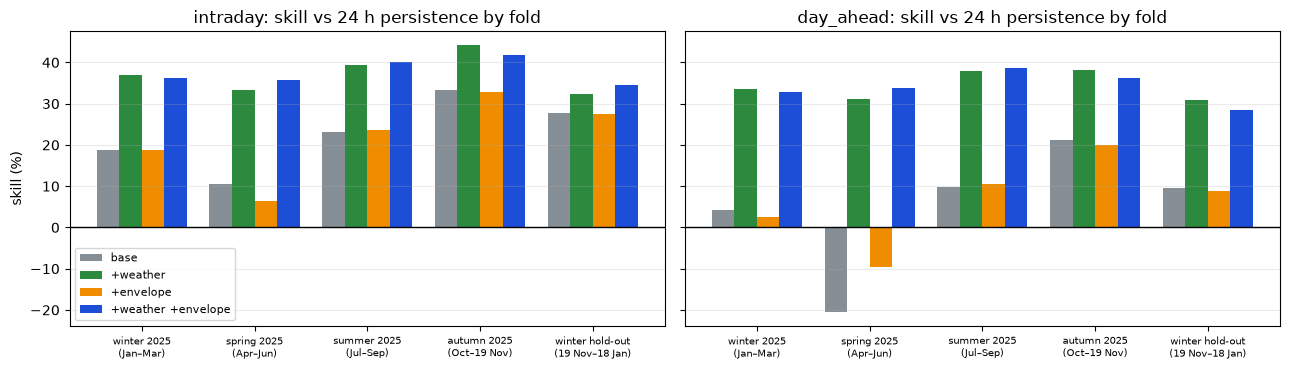

In [10]:
FOLD_ORDER = list(range(len(FOLDS)))


def pooled(config: str, block: str, folds=None) -> pd.DataFrame:
    folds = FOLD_ORDER if folds is None else folds
    return pd.concat([RESULTS[(fi, config, block)].assign(fold=fi) for fi in folds], ignore_index=True)


COLS = {"n": "slots", "mae_kw": "MAE (kW)", "nmae_pct": "nMAE (% of kWc)", "skill_pct": "skill vs persistence (%)",
        "bias_kw": "bias (kW)", "r2": "R²", "coverage_pct": "P10–P90 coverage (%)", "width_kw": "band width (kW)",
        "winkler_kw": "interval score (kW)", "pinball_kw": "mean pinball (kW)"}
board = {(block, cfg): score_rows(pooled(cfg, block)) for block in BLOCKS for cfg in CONFIGS}
board_df = pd.DataFrame(board).T[list(COLS)].astype({"n": int}).rename(columns=COLS)
board_df.index = pd.MultiIndex.from_tuples(board_df.index, names=["block", "configuration"])
display(board_df.round(2))

per_fold = {(block, cfg, fi): score_rows(RESULTS[(fi, cfg, block)]) for block in BLOCKS for cfg in CONFIGS for fi in FOLD_ORDER}
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
colors = {"base": "#868e96", "+weather": "#2b8a3e", "+envelope": "#f08c00", "+weather +envelope": "#1c4ed8"}
for ax, block in zip(axes, BLOCKS):
    x = np.arange(len(FOLD_ORDER))
    for j, cfg in enumerate(CONFIGS):
        vals = [per_fold[(block, cfg, fi)]["skill_pct"] for fi in FOLD_ORDER]
        ax.bar(x + (j - 1.5) * 0.2, vals, 0.2, color=colors[cfg], label=cfg)
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x, [FOLDS[fi]["name"].split(" (")[0] + "\n(" + FOLDS[fi]["name"].split("(")[1] for fi in FOLD_ORDER], fontsize=7)
    ax.set_title(f"{block}: skill vs 24 h persistence by fold")
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel("skill (%)")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [11]:
def day_bootstrap(a: pd.DataFrame, b: pd.DataFrame, n_boot: int = 4000, seed: int = 0) -> tuple[float, float, float]:
    # Relative change (%) of the pooled P50 MAE of `b` against `a` on identical rows; days (of the target slot) are the
    # resampling unit, so day-to-day weather persistence does not make the interval look tighter than it is.
    assert (a.issue.to_numpy() == b.issue.to_numpy()).all() and (a.ts.to_numpy() == b.ts.to_numpy()).all()
    d = pd.DataFrame({"day": pd.DatetimeIndex(a.ts).floor("D"), "ea": (a.p50 - a.actual).abs().to_numpy(),
                      "eb": (b.p50 - b.actual).abs().to_numpy()}).groupby("day").sum()
    idx = np.random.default_rng(seed).integers(0, len(d), (n_boot, len(d)))
    rel = 100 * (d.eb.to_numpy()[idx].sum(axis=1) / d.ea.to_numpy()[idx].sum(axis=1) - 1)
    return 100 * (d.eb.sum() / d.ea.sum() - 1), *np.percentile(rel, [5, 95])


boot = {}
for block in BLOCKS:
    base_frame = pooled("base", block)
    for cfg in list(CONFIGS)[1:]:
        boot[(block, cfg)] = day_bootstrap(base_frame, pooled(cfg, block))
boot_df = pd.DataFrame(boot, index=["change in MAE (%)", "90 % interval low", "90 % interval high"]).T.round(1)
boot_df.index = pd.MultiIndex.from_tuples(boot_df.index, names=["block", "configuration vs base"])
display(Markdown("**Change of the pooled P50 MAE against `base`** — paired, 4000 resamples of the target days"))
display(boot_df)

**Change of the pooled P50 MAE against `base`** — paired, 4000 resamples of the target days

change in MAE (%)  90 % interval low  \
block     configuration vs base                                         
intraday  +weather                           -22.2              -24.9   
          +envelope                            1.7                0.9   
          +weather +envelope                 -23.3              -26.1   
day_ahead +weather                           -35.3              -38.6   
          +envelope                           -3.9               -6.1   
          +weather +envelope                 -36.1              -39.5   

                                 90 % interval high  
block     configuration vs base                      
intraday  +weather                            -19.4  
          +envelope                             2.7  
          +weather +envelope                  -20.5  
day_ahead +weather                            -31.8  
          +envelope                            -1.6  
          +weather +envelope                  -32.5

**P10–P90 band: raw vs conformal** (nominal coverage 80 %)

coverage raw (%)  \
block     configuration      fold                                                
intraday  +weather           winter 2025 (Jan–Mar)                        72.8   
                             spring 2025 (Apr–Jun)                        55.8   
                             summer 2025 (Jul–Sep)                        64.9   
                             autumn 2025 (Oct–19 Nov)                     76.5   
                             winter hold-out (19 Nov–18 Jan)              70.1   
                             pooled                                       65.8   
day_ahead +weather           winter 2025 (Jan–Mar)                        67.3   
                             spring 2025 (Apr–Jun)                        55.9   
                             summer 2025 (Jul–Sep)                        65.3   
                             autumn 2025 (Oct–19 Nov)                     75.1   
                             winter hold-out (19 Nov–18 Jan)              71.4   
                             pooled                                       64.5   
intraday  +weather +envelope winter 2025 (Jan–Mar)                        68.4   
                             spring 2025 (Apr–Jun)                        56.9   
                             summer 2025 (Jul–Sep)                        65.9   
                             autumn 2025 (Oct–19 Nov)                     74.0   
                             winter hold-out (19 Nov–18 Jan)              71.0   
                             pooled                                       65.3   
day_ahead +weather +envelope winter 2025 (Jan–Mar)                        67.3   
                             spring 2025 (Apr–Jun)                        60.8   
                             summer 2025 (Jul–Sep)                        66.4   
                             autumn 2025 (Oct–19 Nov)                     72.3   
                             winter hold-out (19 Nov–18 Jan)              71.7   
                             pooled                                       66.1   

                                                              coverage conformal (%)  \
block     configuration      fold                                                      
intraday  +weather           winter 2025 (Jan–Mar)                              79.3   
                             spring 2025 (Apr–Jun)                              76.9   
                             summer 2025 (Jul–Sep)                              78.8   
                             autumn 2025 (Oct–19 Nov)                           80.5   
                             winter hold-out (19 Nov–18 Jan)                    73.8   
                             pooled                                             78.0   
day_ahead +weather           winter 2025 (Jan–Mar)                              78.4   
                             spring 2025 (Apr–Jun)                              78.2   
                             summer 2025 (Jul–Sep)                              78.5   
                             autumn 2025 (Oct–19 Nov)                           79.4   
                             winter hold-out (19 Nov–18 Jan)                    72.9   
                             pooled                                             77.9   
intraday  +weather +envelope winter 2025 (Jan–Mar)                              79.3   
                             spring 2025 (Apr–Jun)                              77.0   
                             summer 2025 (Jul–Sep)                              78.8   
                             autumn 2025 (Oct–19 Nov)                           79.1   
                             winter hold-out (19 Nov–18 Jan)                    74.9   
                             pooled                                             78.0   
day_ahead +weather +envelope winter 2025 (Jan–Mar)                              78.2   
                             spring 2025 (Apr–Jun)                              7

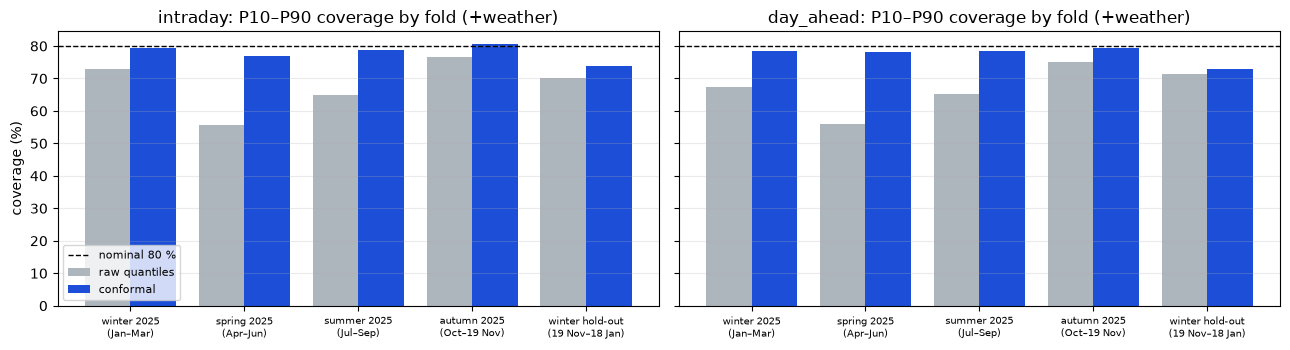

In [12]:
# Conformal recalibration: coverage, width and interval score of the band before / after, per fold and pooled
conf = {}
for block in BLOCKS:
    for cfg in ("base", "+weather", "+weather +envelope"):
        for label, folds in [(FOLDS[fi]["name"], [fi]) for fi in FOLD_ORDER] + [("pooled", FOLD_ORDER)]:
            g = pooled(cfg, block, folds)
            raw, adj = score_rows(g), score_rows(g, ("p10c", "p90c"))
            conf[(block, cfg, label)] = {"coverage raw (%)": raw["coverage_pct"], "coverage conformal (%)": adj["coverage_pct"],
                                         "width raw (kW)": raw["width_kw"], "width conformal (kW)": adj["width_kw"],
                                         "interval score raw (kW)": raw["winkler_kw"], "interval score conformal (kW)": adj["winkler_kw"]}
conf_df = pd.DataFrame(conf).T.round(1)
conf_df.index = pd.MultiIndex.from_tuples(conf_df.index, names=["block", "configuration", "fold"])
display(Markdown("**P10–P90 band: raw vs conformal** (nominal coverage 80 %)"))
display(conf_df.loc[(slice(None), ["+weather", "+weather +envelope"]), :])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, block in zip(axes, BLOCKS):
    sub = conf_df.xs((block, "+weather"), level=("block", "configuration")).drop(index="pooled")
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["coverage raw (%)"], 0.4, color="#adb5bd", label="raw quantiles")
    ax.bar(x + 0.2, sub["coverage conformal (%)"], 0.4, color="#1c4ed8", label="conformal")
    ax.axhline(80, color="black", ls="--", lw=1, label="nominal 80 %")
    ax.set_xticks(x, [n.split(" (")[0] + "\n(" + n.split("(")[1] for n in sub.index], fontsize=7)
    ax.set_title(f"{block}: P10–P90 coverage by fold (+weather)")
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel("coverage (%)")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [13]:
# Sensitivity of the recalibration to the length of the trailing window (the protocol fixed 45 days beforehand)
sens = {}
for block in BLOCKS:
    for days in (14, 45, 90):
        frames = []
        for fi in FOLD_ORDER:
            test, cal = RESULTS[(fi, "+weather", block)], CAL[(fi, "+weather", block)]
            lo_adj, hi_adj = conformal_adjustments(cal, test, block, window_days=days)
            frames.append(apply_conformal(test, lo_adj, hi_adj, ENVS[(fi, "slope")]["max_kw"]))
        r = score_rows(pd.concat(frames, ignore_index=True), ("p10c", "p90c"))
        sens[(block, f"{days} days")] = {"coverage (%)": r["coverage_pct"], "width (kW)": r["width_kw"], "interval score (kW)": r["winkler_kw"]}
sens_df = pd.DataFrame(sens).T.round(1)
sens_df.index = pd.MultiIndex.from_tuples(sens_df.index, names=["block", "trailing window"])
display(Markdown("**Conformal window length — pooled over the five folds (`+weather`)**"))
display(sens_df)

**Conformal window length — pooled over the five folds (`+weather`)**

coverage (%)  width (kW)  interval score (kW)
block     trailing window                                               
intraday  14 days                  77.1       132.4                185.3
          45 days                  78.0       134.5                186.0
          90 days                  78.0       134.8                186.0
day_ahead 14 days                  77.2       133.4                184.4
          45 days                  77.9       136.0                185.3
          90 days                  77.9       136.8                185.4

In [14]:
# Online recalibration vs one frozen set of offsets per fold (what a service without an outcome feed could ship)
froz = {}
for block in BLOCKS:
    for label in ("raw quantiles", "frozen offsets", "online (45-day window)"):
        frames = []
        for fi in FOLD_ORDER:
            test, cal = RESULTS[(fi, "+weather", block)], CAL[(fi, "+weather", block)]
            cap = ENVS[(fi, "slope")]["max_kw"]
            if label == "frozen offsets":
                frames.append(apply_static(test, static_offsets(cal, block, FOLDS[fi]["test_start"]), block, cap))
            else:
                frames.append(test)
        g = pd.concat(frames, ignore_index=True)
        r = score_rows(g, ("p10c", "p90c") if label != "raw quantiles" and "p10c" in g else ("p10", "p90"))
        if label == "raw quantiles":
            r = score_rows(g)
        froz[(block, label)] = {"coverage (%)": r["coverage_pct"], "width (kW)": r["width_kw"], "interval score (kW)": r["winkler_kw"]}
froz_df = pd.DataFrame(froz).T.round(1)
froz_df.index = pd.MultiIndex.from_tuples(froz_df.index, names=["block", "band"])
display(Markdown("**Frozen vs online offsets — pooled over the five folds (`+weather`)**"))
display(froz_df)

**Frozen vs online offsets — pooled over the five folds (`+weather`)**

coverage (%)  width (kW)  \
block     band                                               
intraday  raw quantiles                   65.8       117.1   
          frozen offsets                  74.6       129.1   
          online (45-day window)          78.0       134.5   
day_ahead raw quantiles                   64.5       117.7   
          frozen offsets                  73.6       130.5   
          online (45-day window)          77.9       136.0   

                                  interval score (kW)  
block     band                                         
intraday  raw quantiles                         204.4  
          frozen offsets                        188.5  
          online (45-day window)                186.0  
day_ahead raw quantiles                         206.8  
          frozen offsets                        190.4  
          online (45-day window)                185.3

## 8 · What the learned envelope changes — and what it does not

The point of an envelope is a clear-sky index that means the same thing all year: **≈ 1 whenever the sky is clear,
whatever the sun height or the season**. To test that without circularity, "clear" is defined independently of
the PV series and of any envelope: slots where all three weather models forecast a clear sky (forecast clear-sky
index ≥ 0.93 in ICON-EU, ECMWF IFS *and* ARPEGE, and ICON-EU cloud cover ≤ 15 %). Both envelopes are fitted on data
before 2 Nov 2024 (fold 1); the table is the median clear-sky index of those slots per month, in-sample
(months before the cut-off) and out-of-sample (after it).

A third envelope is included as an **exploratory** diagnostic, *not* a candidate for the shipped model: it is fitted
only on those clear slots, as a function of sun elevation and azimuth alone (no season), 80th percentile. The
learned envelope's 98th-percentile design mixes "how often is the sky clear" with "how bright is a clear sky",
and the exploratory variant shows what removing that confusion would give.

**Median clear-sky index of weather-consensus clear slots, by month**

,slope,"learned (98th pct, season)","clear-slot, sun position only (exploratory)",clear slots,fitted on this month?
ts_utc,,,,,
2024-05,0.76,0.88,0.95,46,yes
2024-06,0.84,0.88,0.95,50,yes
2024-07,0.84,0.88,0.97,88,yes
2024-08,0.84,0.89,0.98,127,yes
2025-01,0.37,0.47,0.59,41,no
2025-03,0.70,0.86,1.02,309,no
2025-04,0.80,0.95,0.98,442,no
2025-05,0.81,0.92,0.97,309,no
2025-06,0.89,0.97,1.04,259,no


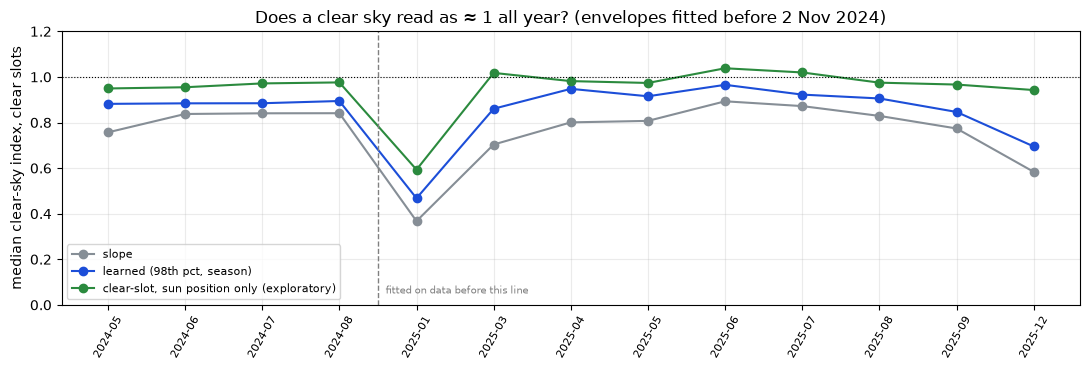

clear-slot index out-of-sample — all months: slope 0.74±0.17; learned (98t 0.84±0.16; clear-slot,  0.95±0.14
Mar–Sep 2025 only: slope 0.81±0.06; learned (98t 0.91±0.04; clear-slot,  1.00±0.03
clear slots available to the exploratory fit: 367


In [15]:
def fit_clear_slot_envelope(pv: pd.Series, until: pd.Timestamp, quantile: float = 0.8) -> dict:
    # Exploratory: upper quantile of output over weather-consensus clear slots, as a function of sun position only.
    u = pv.dropna()
    u = u[u.index < until]
    g, nw = GEO.reindex(u.index), nwp_slot_features(u.index)
    clear = ((nw[["kcs_icon_k1", "kcs_ecmwf_k1", "kcs_arpege_k1"]] >= 0.93).all(axis=1) & (nw.cloud_k1 <= 15.0)).to_numpy() & (g.cs_ghi >= 30).to_numpy()
    feats = ["elevation", "azimuth"]
    model = lgb.LGBMRegressor(objective="quantile", alpha=quantile, n_estimators=150, max_depth=3, num_leaves=8, learning_rate=0.05,
                              min_child_samples=40, subsample=0.8, subsample_freq=1, random_state=42, verbose=-1)
    model.fit(g.loc[clear, feats], u[clear])
    return {"type": "learned", "model": model, "features": feats, "n_clear": int(clear.sum()),
            "max_kw": round(min(float(np.quantile(u.to_numpy(), 0.999)), CAPACITY_KWC), 3)}


env_diag = {"slope": ENVS[(0, "slope")], "learned (98th pct, season)": ENVS[(0, "learned")],
            "clear-slot, sun position only (exploratory)": fit_clear_slot_envelope(copal_pv, FOLDS[0]["train_end"])}
obs = copal_pv.dropna().index
nw_obs, geo_obs = nwp_slot_features(obs), GEO.reindex(obs)
is_clear = ((nw_obs[["kcs_icon_k1", "kcs_ecmwf_k1", "kcs_arpege_k1"]] >= 0.93).all(axis=1) & (nw_obs.cloud_k1 <= 15.0)).to_numpy() & (geo_obs.cs_ghi >= 30).to_numpy()
month_of = pd.Index(obs.strftime("%Y-%m"))
n_clear = pd.Series(1, index=month_of[is_clear]).groupby(level=0).sum()
clear = {}
for name, env in env_diag.items():
    g = make_grid(copal_pv, env).loc[obs]
    sel = is_clear & g.kcs.notna().to_numpy()
    clear[name] = g.kcs[sel].groupby(month_of[sel]).median()
clear = pd.DataFrame(clear)
clear["clear slots"] = n_clear
clear = clear[clear["clear slots"] >= 40]
cut_month = f"{FOLDS[0]['train_end']:%Y-%m}"
clear["fitted on this month?"] = np.where(clear.index < cut_month, "yes", "no")
display(Markdown("**Median clear-sky index of weather-consensus clear slots, by month**"))
display(clear.round(2))

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(clear))
for (name, colr) in zip(env_diag, ("#868e96", "#1c4ed8", "#2b8a3e")):
    ax.plot(x, clear[name], marker="o", color=colr, label=name)
ax.axhline(1.0, color="black", lw=0.8, ls=":")
ax.axvline(np.searchsorted(clear.index, cut_month) - 0.5, color="grey", lw=1, ls="--")
ax.text(np.searchsorted(clear.index, cut_month) - 0.4, 0.05, "fitted on data before this line", fontsize=7, color="grey")
ax.set_xticks(x, clear.index, rotation=60, fontsize=8)
ax.set_ylim(0, 1.2)
ax.set_ylabel("median clear-sky index, clear slots")
ax.set_title("Does a clear sky read as ≈ 1 all year? (envelopes fitted before 2 Nov 2024)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
oos = clear[clear["fitted on this month?"] == "no"].drop(columns=["clear slots", "fitted on this month?"])
mar_sep = oos[(oos.index >= "2025-03") & (oos.index <= "2025-09")]
print(f"clear-slot index out-of-sample — all months: " + "; ".join(f"{c[:12]} {oos[c].mean():.2f}±{oos[c].std():.2f}" for c in oos)
      + f"\nMar–Sep 2025 only: " + "; ".join(f"{c[:12]} {mar_sep[c].mean():.2f}±{mar_sep[c].std():.2f}" for c in mar_sep)
      + f"\nclear slots available to the exploratory fit: {env_diag['clear-slot, sun position only (exploratory)']['n_clear']}")

## 9 · External check on the Elia Luxembourg-province series

The same test as `ECC_PV_Evaluation_Elia.ipynb`, now for the candidate configurations. The models are the **winter hold-out fold's**
(trained on Copal data before 20 Sep 2025, nothing from Elia), applied to the Elia series — measured MW ÷ monitored
capacity × 973.81 kWc, "Copal-equivalent kW" — with

* the envelope **refitted on Elia data before the model cut-off** (slope or learned, matching the configuration),
* the weather features of the same location (the province is ≈ 100 km away, an acknowledged approximation),
* the online conformal recalibration driven by Elia's own recent outcomes, warmed up on 20 Sep → 19 Nov 2025.

Two windows, as before: the 60 days that were Copal's hold-out (19 Nov 2025 → 18 Jan 2026: same sky, other source)
and the **255 days after Copal's data end, 19 Jan → 30 Sep 2026 — spring, summer and early autumn**, which no model
here has seen. Benchmarks: 24 h persistence, and Elia's own 6 PM day-ahead forecast (weather-driven; our day-ahead
model issued at 18 UTC is two hours *later*, so timing does not favour Elia).

In [16]:
# ---- Elia series, as in the evaluation notebook (same cache file) --------------------------------------
ELIA_URL = "https://opendata.elia.be/api/explore/v2.1/catalog/datasets/ods032/exports/csv"
elia_fields = ["datetime", "measured", "monitoredcapacity", "loadfactor", "dayaheadforecast", "dayaheadconfidence10", "dayaheadconfidence90"]
elia_cache = CACHE_DIR / f"elia_ods032_luxembourg_{COPAL_FIRST:%Y%m%d}_{ELIA_END:%Y%m%d}.csv"
if not elia_cache.is_file():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    query = urlencode({
        "where": f"region=\"Luxembourg\" AND datetime>=date'{COPAL_FIRST:%Y-%m-%dT%H:%M:%SZ}' AND datetime<date'{ELIA_END:%Y-%m-%dT%H:%M:%SZ}'",
        "select": ",".join(elia_fields), "order_by": "datetime"})
    with urlopen(Request(f"{ELIA_URL}?{query}", headers={"User-Agent": "enertef-pv-forecasting"}), timeout=300) as resp:
        payload = resp.read()
    elia_cache.with_suffix(".part").write_bytes(payload)
    elia_cache.with_suffix(".part").replace(elia_cache)
    print(f"downloaded {len(payload) / 1e6:.1f} MB from Elia")
raw_e = pd.read_csv(elia_cache, sep=";", encoding="utf-8-sig")
elia = raw_e.assign(ts_utc=pd.to_datetime(raw_e["datetime"], utc=True)).drop(columns="datetime").set_index("ts_utc").sort_index()
elia_pv = (elia.measured / elia.monitoredcapacity * CAPACITY_KWC).clip(0.0, CAPACITY_KWC).rename("pv_kw")
ELIA_DA = pd.DataFrame({"p10": elia.dayaheadconfidence10, "p50": elia.dayaheadforecast, "p90": elia.dayaheadconfidence90}
                       ).div(elia.monitoredcapacity, axis=0) * CAPACITY_KWC
print(f"Elia Luxembourg: {elia.index[0]:%d %b %Y} → {elia.index[-1]:%d %b %Y}, missing measured {int(elia.measured.isna().sum())}, "
      f"monitored capacity {elia.monitoredcapacity.iloc[0]:.0f} → {elia.monitoredcapacity.iloc[-1]:.0f} MW")

WINDOWS = ("same 60 days as Copal's hold-out", "new period (19 Jan → 30 Sep 2026)")
EVAL_FOLD = len(FOLDS) - 1                                    # the winter hold-out fold
ef = FOLDS[EVAL_FOLD]
ELIA_SLOTS = nwp_slot_features(pd.date_range(elia_pv.index[0], elia_pv.index[-1] + pd.Timedelta(days=1), freq=SLOT))
ELIA_ENVS = {kind: fit_envelope(kind, elia_pv, ef["train_end"]) for kind in ("slope", "learned")}
ELIA = {}                                                      # (config, block) → scored frame with window / month columns
for kind, env in ELIA_ENVS.items():
    grid = make_grid(elia_pv, env)
    for block in BLOCKS:
        s = build_samples(block, ef["train_end"], ELIA_END, grid, ELIA_SLOTS)
        is_test = (s.issue >= ef["test_start"]).to_numpy()
        for name, cfg in CONFIGS.items():
            if cfg["env"] != kind:
                continue
            feats = FEATURES_NWP if cfg["nwp"] else FEATURES_BASE
            frame = forecast_frame(s, predict_kcs(MODELS[(EVAL_FOLD, name, block)], s[feats]), env, "")
            cal, test = frame[~is_test].reset_index(drop=True), frame[is_test].reset_index(drop=True)
            lo_adj, hi_adj = conformal_adjustments(cal, test, block)
            out = apply_conformal(test, lo_adj, hi_adj, env["max_kw"])
            out["window"] = np.where(out.issue < COPAL_LAST, WINDOWS[0], WINDOWS[1])
            out["month"] = pd.DatetimeIndex(out.ts).strftime("%Y-%m")
            ELIA[(name, block)] = out
print("Elia envelopes (fitted before the model cut-off):",
      {k: (v["kw_per_wm2"], v["max_kw"]) if k == "slope" else ("learned", v["max_kw"]) for k, v in ELIA_ENVS.items()})

Elia Luxembourg: 11 Oct 2023 → 30 Sep 2026, missing measured 369, monitored capacity 180 → 368 MW


Elia envelopes (fitted before the model cut-off): {'slope': (0.97381, 619.943), 'learned': ('learned', 619.943)}


In [17]:
ecols = {"n": "slots", "nmae_pct": "nMAE (% of capacity)", "skill_pct": "skill vs persistence (%)", "bias_kw": "bias (kW)",
         "coverage_pct": "P10–P90 coverage, raw (%)"}
rows = {}
for block in BLOCKS:
    for cfg in CONFIGS:
        for w in (*WINDOWS, "all"):
            g = ELIA[(cfg, block)] if w == "all" else ELIA[(cfg, block)][ELIA[(cfg, block)].window == w]
            r = score_rows(g)
            rows[(block, cfg, w)] = {**{k: r[k] for k in ecols}, "coverage conformal (%)": score_rows(g, ("p10c", "p90c"))["coverage_pct"]}
elia_df = pd.DataFrame(rows).T.astype({"n": int}).rename(columns=ecols)
elia_df.index = pd.MultiIndex.from_tuples(elia_df.index, names=["block", "configuration", "window"])
display(Markdown("**Elia series — the Copal-trained models, by configuration and window**"))
display(elia_df.round(2))

# the transfer gap: the very same 60 days, Copal (hold-out fold) against Elia
gap = {}
for block in BLOCKS:
    for cfg in CONFIGS:
        c = score_rows(RESULTS[(EVAL_FOLD, cfg, block)])
        e = score_rows(ELIA[(cfg, block)][ELIA[(cfg, block)].window == WINDOWS[0]])
        gap[(block, cfg)] = {"Copal nMAE (%)": c["nmae_pct"], "Elia nMAE (%)": e["nmae_pct"], "Copal bias (kW)": c["bias_kw"],
                             "Elia bias (kW)": e["bias_kw"], "Copal skill (%)": c["skill_pct"], "Elia skill (%)": e["skill_pct"]}
gap_df = pd.DataFrame(gap).T.round(2)
gap_df.index = pd.MultiIndex.from_tuples(gap_df.index, names=["block", "configuration"])
display(Markdown("**Transfer gap on the same 60 days** (previous release for reference: Copal 1.87 / 2.38 % nMAE, bias −0.2 / −2.6 kW; Elia 3.85 / 5.04 %, −15 / −18 kW)"))
display(gap_df)

**Elia series — the Copal-trained models, by configuration and window**

slots  \
block     configuration      window                                     
intraday  base               same 60 days as Copal's hold-out    5265   
                             new period (19 Jan → 30 Sep 2026)  35139   
                             all                                40404   
          +weather           same 60 days as Copal's hold-out    5265   
                             new period (19 Jan → 30 Sep 2026)  35139   
                             all                                40404   
          +envelope          same 60 days as Copal's hold-out    5265   
                             new period (19 Jan → 30 Sep 2026)  35139   
                             all                                40404   
          +weather +envelope same 60 days as Copal's hold-out    5265   
                             new period (19 Jan → 30 Sep 2026)  35139   
                             all                                40404   
day_ahead base               same 60 days as Copal's hold-out    5302   
                             new period (19 Jan → 30 Sep 2026)  38864   
                             all                                44166   
          +weather           same 60 days as Copal's hold-out    5302   
                             new period (19 Jan → 30 Sep 2026)  38864   
                             all                                44166   
          +envelope          same 60 days as Copal's hold-out    5302   
                             new period (19 Jan → 30 Sep 2026)  38864   
                             all                                44166   
          +weather +envelope same 60 days as Copal's hold-out    5302   
                             new period (19 Jan → 30 Sep 2026)  38864   
                             all                                44166   

                                                                nMAE (% of capacity)  \
block     configuration      window                                                    
intraday  base               same 60 days as Copal's hold-out                   3.85   
                             new period (19 Jan → 30 Sep 2026)                  5.38   
                             all                                                5.18   
          +weather           same 60 days as Copal's hold-out                   3.53   
                             new period (19 Jan → 30 Sep 2026)                  4.93   
                             all                                                4.75   
          +envelope          same 60 days as Copal's hold-out                   4.42   
                             new period (19 Jan → 30 Sep 2026)                  4.89   
                             all                                                4.83   
          +weather +envelope same 60 days as Copal's hold-out                   4.17   
                             new period (19 Jan → 30 Sep 2026)                  3.96   
                             all                                                3.99   
day_ahead base               same 60 days as Copal's hold-out                   4.91   
                             new period (19 Jan → 30 Sep 2026)                  7.34   
                             all                                                7.05   
          +weather           same 60 days as Copal's hold-out                   3.78   
                             new period (19 Jan → 30 Sep 2026)                  5.20   
                             all                                                5.03   
          +envelope          same 60 days as Copal's hold-out                   5.96   
                             new period (19 Jan → 30 Sep 2026)                  6.80   
                             all                                                6.70   
          +weather +envelope same 60 days as Copal's hold-out                   4.69   
                             new period (19 Jan → 30 

**Transfer gap on the same 60 days** (previous release for reference: Copal 1.87 / 2.38 % nMAE, bias −0.2 / −2.6 kW; Elia 3.85 / 5.04 %, −15 / −18 kW)

Copal nMAE (%)  Elia nMAE (%)  Copal bias (kW)  \
block     configuration                                                        
intraday  base                          1.84           3.85            -0.31   
          +weather                      1.72           3.53             2.82   
          +envelope                     1.84           4.42            -0.84   
          +weather +envelope            1.66           4.17             1.71   
day_ahead base                          2.28           4.91            -2.91   
          +weather                      1.74           3.78             1.21   
          +envelope                     2.30           5.96            -1.83   
          +weather +envelope            1.80           4.69             0.82   

                              Elia bias (kW)  Copal skill (%)  Elia skill (%)  
block     configuration                                                        
intraday  base                        -16.92            27.65           23.40  
          +weather                    -11.34            32.28           29.88  
          +envelope                    14.01            27.56           12.16  
          +weather +envelope           23.88            34.61           17.22  
day_ahead base                        -17.00             9.51            2.98  
          +weather                    -11.31            30.89           25.20  
          +envelope                    18.98             8.79          -17.94  
          +weather +envelope           24.22            28.52            7.20

**Transfer bias on Elia** (mean absolute monthly P50 bias, % of capacity)

,transfer bias (% of capacity)
base,1.79
+weather,2.25
+envelope,1.80
+weather +envelope,1.64


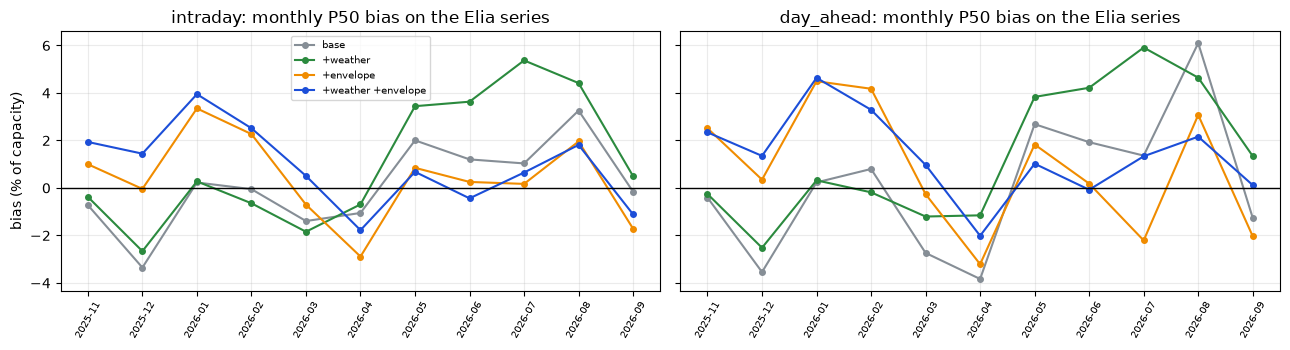

In [18]:
# ---- Transfer bias: mean over the test months and both blocks of |monthly P50 bias|, % of capacity -----------
def transfer_bias(cfg: str) -> float:
    vals = []
    for block in BLOCKS:
        m = ELIA[(cfg, block)].assign(err=lambda d: d.p50 - d.actual).groupby("month").err.mean()
        vals.append((m.abs() / CAPACITY_KWC * 100).mean())
    return float(np.mean(vals))


tb = pd.Series({cfg: transfer_bias(cfg) for cfg in CONFIGS})
display(Markdown("**Transfer bias on Elia** (mean absolute monthly P50 bias, % of capacity)"))
display(tb.round(2).to_frame("transfer bias (% of capacity)"))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, block in zip(axes, BLOCKS):
    for cfg in CONFIGS:
        m = ELIA[(cfg, block)].assign(err=lambda d: d.p50 - d.actual).groupby("month").err.mean() / CAPACITY_KWC * 100
        ax.plot(m.index, m.values, marker="o", ms=4, color=colors[cfg], label=cfg)
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(range(len(m)), m.index, rotation=60, fontsize=7)
    ax.set_title(f"{block}: monthly P50 bias on the Elia series")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("bias (% of capacity)")
axes[0].legend(fontsize=7)
fig.tight_layout()
plt.show()

**Next-day forecasts issued 18 UTC on D-1 — same slots, same actuals**

slots  \
window                            forecast                                      
same 60 days as Copal's hold-out  base                                 1768.0   
                                  +weather                             1768.0   
                                  +envelope                            1768.0   
                                  +weather +envelope                   1768.0   
                                  +weather +envelope, conformal band   1768.0   
                                  Elia day-ahead 6 PM                  1768.0   
                                  persistence (24 h)                   1768.0   
new period (19 Jan → 30 Sep 2026) base                                12494.0   
                                  +weather                            12494.0   
                                  +envelope                           12494.0   
                                  +weather +envelope                  12494.0   
                                  +weather +envelope, conformal band  12494.0   
                                  Elia day-ahead 6 PM                 12494.0   
                                  persistence (24 h)                  12494.0   
all                               base                                14262.0   
                                  +weather                            14262.0   
                                  +envelope                           14262.0   
                                  +weather +envelope                  14262.0   
                                  +weather +envelope, conformal band  14262.0   
                                  Elia day-ahead 6 PM                 14262.0   
                                  persistence (24 h)                  14262.0   

                                                                      nMAE (% of capacity)  \
window                            forecast                                                   
same 60 days as Copal's hold-out  base                                                4.98   
                                  +weather                                            3.80   
                                  +envelope                                           5.97   
                                  +weather +envelope                                  4.70   
                                  +weather +envelope, conformal band                  4.70   
                                  Elia day-ahead 6 PM                                 2.58   
                                  persistence (24 h)                                  5.10   
new period (19 Jan → 30 Sep 2026) base                                                7.68   
                                  +weather                                            5.43   
                                  +envelope                                           7.19   
                                  +weather +envelope                                  4.47   
                                  +weather +envelope, conformal band                  4.47   
                                  Elia day-ahead 6 PM                                 3.78   
                                  persistence (24 h)                                  7.28   
all                               base                                                7.35   
                                  +weather                                            5.23   
                                  +envelope                                           7.04   
                                  +weather +envelope                                  4.50   
                                  +weather +envelope, conformal band                  4.50   
                                  Elia day-ahead 6 PM                                 3.63   
                                  persistence (24 h)                                  7.01   

                                             

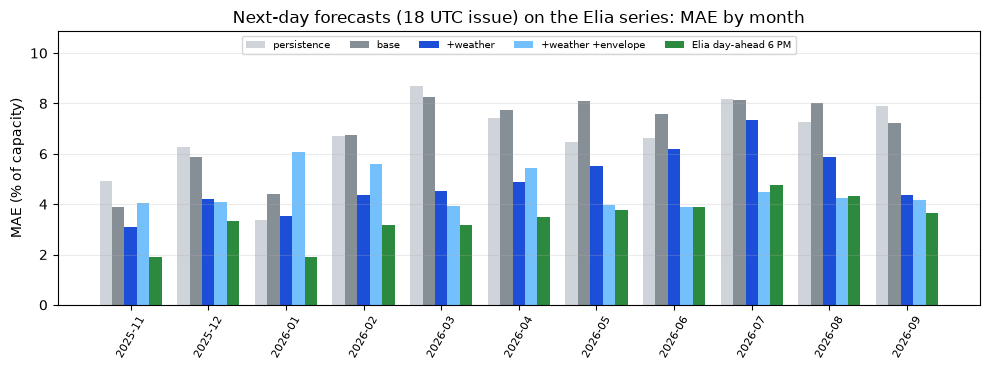

In [19]:
# ---- Benchmark: next-day forecasts issued 18 UTC, against Elia's own 6 PM day-ahead forecast ---------------
def with_elia(g: pd.DataFrame) -> pd.DataFrame:
    d = g[g.issue.dt.hour == 18].copy()
    ref = ELIA_DA.reindex(pd.DatetimeIndex(d.ts))
    d["elia_p10"], d["elia_p50"], d["elia_p90"] = ref.p10.to_numpy(), ref.p50.to_numpy(), ref.p90.to_numpy()
    return d.dropna(subset=["elia_p50"])


rows = {}
for w in (*WINDOWS, "all"):
    base_d = with_elia(ELIA[("base", "day_ahead")])
    ref = base_d if w == "all" else base_d[base_d.window == w]
    a = ref.actual.to_numpy()

    def row(pred, lo=None, hi=None, n=None):
        err = pred - a
        return {"slots": len(ref), "nMAE (% of capacity)": 100 * np.mean(np.abs(err)) / CAPACITY_KWC, "bias (kW)": np.mean(err),
                "R²": 1 - np.sum(err ** 2) / np.sum((a - a.mean()) ** 2),
                "coverage (%)": np.nan if lo is None else 100 * np.mean((lo <= a) & (a <= hi))}

    for cfg in CONFIGS:
        d = with_elia(ELIA[(cfg, "day_ahead")])
        d = d if w == "all" else d[d.window == w]
        rows[(w, cfg)] = row(d.p50.to_numpy(), d.p10.to_numpy(), d.p90.to_numpy())
        if cfg == "+weather +envelope":
            rows[(w, f"{cfg}, conformal band")] = row(d.p50.to_numpy(), d.p10c.to_numpy(), d.p90c.to_numpy())
    rows[(w, "Elia day-ahead 6 PM")] = row(ref.elia_p50.to_numpy(), ref.elia_p10.to_numpy(), ref.elia_p90.to_numpy())
    rows[(w, "persistence (24 h)")] = row(ref.pers.to_numpy())
bench = pd.DataFrame(rows).T
bench.index = pd.MultiIndex.from_tuples(bench.index, names=["window", "forecast"])
display(Markdown("**Next-day forecasts issued 18 UTC on D-1 — same slots, same actuals**"))
display(bench.round(2))

fig, ax = plt.subplots(figsize=(10, 3.8))
mm = {}
for label, g in (("+weather +envelope", ELIA[("+weather +envelope", "day_ahead")]), ("+weather", ELIA[("+weather", "day_ahead")]),
                 ("base", ELIA[("base", "day_ahead")])):
    d = with_elia(g)
    mm[label] = (d.p50 - d.actual).abs().groupby(d.month).mean() * 100 / CAPACITY_KWC
d = with_elia(ELIA[("+weather +envelope", "day_ahead")])
mm["Elia day-ahead 6 PM"] = (d.elia_p50 - d.actual).abs().groupby(d.month).mean() * 100 / CAPACITY_KWC
mm["persistence"] = (d.pers - d.actual).abs().groupby(d.month).mean() * 100 / CAPACITY_KWC
mm = pd.DataFrame(mm)
x = np.arange(len(mm))
for j, (col, colr) in enumerate((("persistence", "#ced4da"), ("base", "#868e96"), ("+weather", "#1c4ed8"),
                                 ("+weather +envelope", "#74c0fc"), ("Elia day-ahead 6 PM", "#2b8a3e"))):
    ax.bar(x + (j - 2) * 0.16, mm[col], 0.16, color=colr, label=col)
ax.set_xticks(x, mm.index, rotation=60, fontsize=8)
ax.set_ylabel("MAE (% of capacity)")
ax.set_title("Next-day forecasts (18 UTC issue) on the Elia series: MAE by month")
ax.legend(fontsize=7, ncol=5, loc="upper center")
ax.set_ylim(top=mm.to_numpy().max() * 1.25)
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## 10 · Decisions, final fit and export

The adoption rules of the protocol are applied by code to the numbers above; nothing here is a judgement call
made after the fact.

In [20]:
# ---- R1 weather: day-ahead MAE −3 % or better, 90 % interval entirely below zero, intraday not worse ----------
chg = {block: day_bootstrap(pooled("base", block), pooled("+weather", block)) for block in BLOCKS}
r1 = chg["day_ahead"][0] <= -3.0 and chg["day_ahead"][2] < 0.0 and chg["intraday"][0] <= 0.0
# ---- R2 envelope, given weather: pooled MAE not higher (interval not entirely above zero), transfer bias −30 % --
env_chg = {block: day_bootstrap(pooled("+weather", block), pooled("+weather +envelope", block)) for block in BLOCKS}
bias_cut = 100 * (1 - tb["+weather +envelope"] / tb["+weather"])
r2_acc = all(env_chg[b][1] <= 0.0 for b in BLOCKS)          # lower end of the interval ≤ 0 → not significantly worse
r2 = r2_acc and bias_cut >= 30.0
# ---- R3 conformal: mean |coverage − 80| and the interval score both fall (config chosen by R1/R2, pooled folds) ----
ship_name = "+weather +envelope" if (r1 and r2) else ("+weather" if r1 else ("+envelope" if r2 else "base"))
cov_gap_raw = np.mean([abs(score_rows(pooled(ship_name, b))["coverage_pct"] - 80) for b in BLOCKS])
cov_gap_adj = np.mean([abs(score_rows(pooled(ship_name, b), ("p10c", "p90c"))["coverage_pct"] - 80) for b in BLOCKS])
win_raw = np.mean([score_rows(pooled(ship_name, b))["winkler_kw"] for b in BLOCKS])
win_adj = np.mean([score_rows(pooled(ship_name, b), ("p10c", "p90c"))["winkler_kw"] for b in BLOCKS])
r3 = cov_gap_adj < cov_gap_raw and win_adj < win_raw

# the previous release's bake-off fit times (all blocks, per seed) — the reference for the speed decision
PREV_FIT = {"sklearn_gbr": 480.0, "lightgbm": 4.0}
decisions = pd.DataFrame([
    {"component": "weather features", "rule": "day-ahead MAE ≤ −3 %, 90 % interval < 0, intraday not worse",
     "evidence": f"day-ahead {chg['day_ahead'][0]:+.1f} % [{chg['day_ahead'][1]:+.1f}, {chg['day_ahead'][2]:+.1f}], intraday {chg['intraday'][0]:+.1f} % [{chg['intraday'][1]:+.1f}, {chg['intraday'][2]:+.1f}]",
     "adopted": r1},
    {"component": "learned envelope", "rule": "MAE not higher with weather in place AND transfer bias on Elia −30 %",
     "evidence": (f"MAE change given weather: intraday {env_chg['intraday'][0]:+.1f} % [{env_chg['intraday'][1]:+.1f}, {env_chg['intraday'][2]:+.1f}], "
                  f"day-ahead {env_chg['day_ahead'][0]:+.1f} % [{env_chg['day_ahead'][1]:+.1f}, {env_chg['day_ahead'][2]:+.1f}]; "
                  f"transfer bias {tb['+weather']:.2f} → {tb['+weather +envelope']:.2f} % of capacity ({-bias_cut:+.0f} %)"),
     "adopted": r2},
    {"component": "conformal band", "rule": "mean |coverage − 80| and interval score both fall",
     "evidence": f"|coverage − 80|: {cov_gap_raw:.1f} → {cov_gap_adj:.1f} pts; interval score {win_raw:.0f} → {win_adj:.0f} kW", "adopted": r3},
    {"component": "LightGBM", "rule": "(decided by speed: the previous release's bake-off put it 2–2.5 % ahead of GBR at about 1/100 of the fit time)",
     "evidence": (f"{np.mean(FIT_SECONDS):.1f} s per quantile model here ({len(FIT_SECONDS)} fits timed, median {np.median(FIT_SECONDS):.1f} s); "
                  f"previous release's bake-off, all blocks per seed: {PREV_FIT['sklearn_gbr']:.0f} s scikit-learn GBR vs {PREV_FIT['lightgbm']:.0f} s LightGBM"), "adopted": True},
])
with pd.option_context("display.max_colwidth", None):
    display(decisions)
SHIP = {"nwp": ship_name in ("+weather", "+weather +envelope"), "env": CONFIGS[ship_name]["env"], "conformal": bool(r3), "config": ship_name}
print(f"shipped configuration: {SHIP}")

,component,rule,evidence,adopted
0,weather features,"day-ahead MAE ≤ −3 %, 90 % interval < 0, intraday not worse","day-ahead -35.3 % [-38.6, -31.8], intraday -22.2 % [-24.9, -19.4]",True
1,learned envelope,MAE not higher with weather in place AND transfer bias on Elia −30 %,"MAE change given weather: intraday -1.4 % [-2.5, -0.4], day-ahead -1.3 % [-2.3, -0.4]; transfer bias 2.25 → 1.64 % of capacity (-27 %)",False
2,conformal band,mean |coverage − 80| and interval score both fall,|coverage − 80|: 14.8 → 2.0 pts; interval score 206 → 186 kW,True
3,LightGBM,(decided by speed: the previous release's bake-off put it 2–2.5 % ahead of GBR at about 1/100 of the fit time),"0.7 s per quantile model here (40 fits timed, median 0.7 s); previous release's bake-off, all blocks per seed: 480 s scikit-learn GBR vs 4 s LightGBM",True


shipped configuration: {'nwp': True, 'env': 'slope', 'conformal': True, 'config': '+weather'}


### Final fit

Same scheme as every fold, with the test fold empty: models fitted on all Copal data older than 60 days before the
last observation, the 60 days in between supply the calibration of the band. With the current export that is
exactly the previous release's training window, so the two are trained on the same data. When a newer Leneda
export is dropped into `Data/`, the same cell trains on the extended history.

In [21]:
SHIP_TRAIN_END = COPAL_LAST - pd.Timedelta(days=CAL_DAYS)
ship_env = fit_envelope(SHIP["env"], copal_pv, SHIP_TRAIN_END)
ship_grid = make_grid(copal_pv, ship_env)
ship_feats = FEATURES_NWP if SHIP["nwp"] else FEATURES_BASE
SHIP_MODELS, SHIP_CAL, SHIP_OFFSETS, SHIP_EV = {}, {}, {}, {}
for block in BLOCKS:
    s = build_samples(block, COPAL_FIRST, COPAL_LAST, ship_grid, NWP_SLOTS_COPAL)
    train = s[(s.issue < SHIP_TRAIN_END) & (s.ts < SHIP_TRAIN_END) & s.target_kcs.notna()]
    ev = s[s.issue >= SHIP_TRAIN_END]
    SHIP_MODELS[block] = fit_quantiles(train[ship_feats], train.target_kcs.to_numpy())
    SHIP_CAL[block] = forecast_frame(ev, predict_kcs(SHIP_MODELS[block], ev[ship_feats]), ship_env, "cal")
    SHIP_OFFSETS[block] = static_offsets(SHIP_CAL[block], block, COPAL_LAST)
    SHIP_EV[block] = ev
    print(f"{block:9s} trained on {len(train):,} rows before {SHIP_TRAIN_END:%d %b %Y}; "
          f"frozen band offsets (lo, hi, n) per lead bucket: "
          + ", ".join(f"{LEAD_BUCKETS[block][i]:g}–{LEAD_BUCKETS[block][i + 1]:g} h: ({o[0]:+.3f}, {o[1]:+.3f}, {o[2]:,})" for i, o in SHIP_OFFSETS[block].items()))

# the previous release's held-out window, scored with the shipped models: the like-for-like comparison
PREV_HOLDOUT = {
    "intraday": {"n": 5265, "nmae_capacity_pct": 1.868, "skill_vs_persistence_pct": 26.06,
                 "coverage_p10_p90_pct": 71.7, "bias_kw": -0.245},
    "day_ahead": {"n": 5253, "nmae_capacity_pct": 2.385, "skill_vs_persistence_pct": 4.78,
                  "coverage_p10_p90_pct": 67.3, "bias_kw": -2.636},
}
cmp_rows = {}
for block in BLOCKS:
    g = SHIP_CAL[block]
    g = g[(pd.DatetimeIndex(g.issue) >= TRAIN_END) & (pd.DatetimeIndex(g.issue) < COPAL_LAST)]
    r, pub = score_rows(g), PREV_HOLDOUT[block]
    cmp_rows[(block, "previous release (history-only, scikit-learn)")] = {"slots": pub["n"], "nMAE (%)": pub["nmae_capacity_pct"], "skill vs persistence (%)": pub["skill_vs_persistence_pct"],
                                               "coverage raw (%)": pub["coverage_p10_p90_pct"], "bias (kW)": pub["bias_kw"]}
    cmp_rows[(block, f"current release ({SHIP['config']})")] = {"slots": r["n"], "nMAE (%)": r["nmae_pct"], "skill vs persistence (%)": r["skill_pct"],
                                                       "coverage raw (%)": r["coverage_pct"], "bias (kW)": r["bias_kw"]}
cmp_df = pd.DataFrame(cmp_rows).T.round(2).astype({"slots": int})
cmp_df.index = pd.MultiIndex.from_tuples(cmp_df.index, names=["block", "model"])
display(Markdown("**Held-out window (19 Nov 2025 → 18 Jan 2026), shipped models — same training data as the previous release**"))
display(cmp_df)

intraday  trained on 95,620 rows before 19 Nov 2025; frozen band offsets (lo, hi, n) per lead bucket: 0–1 h: (+0.065, -0.002, 720), 1–3 h: (+0.074, -0.006, 1,307), 3–6 h: (+0.083, -0.008, 1,883)


day_ahead trained on 103,998 rows before 19 Nov 2025; frozen band offsets (lo, hi, n) per lead bucket: 6–12 h: (+0.073, +0.000, 1,307), 12–18 h: (+0.075, -0.001, 1,307), 18–24 h: (+0.092, -0.000, 1,307)


**Held-out window (19 Nov 2025 → 18 Jan 2026), shipped models — same training data as the previous release**

slots  nMAE (%)  \
block     model                                                            
intraday  previous release (history-only, scikit-learn)   5265      1.87   
          current release (+weather)                      5265      1.69   
day_ahead previous release (history-only, scikit-learn)   5253      2.38   
          current release (+weather)                      5253      1.74   

                                                         skill vs persistence (%)  \
block     model                                                                     
intraday  previous release (history-only, scikit-learn)                     26.06   
          current release (+weather)                                        33.75   
day_ahead previous release (history-only, scikit-learn)                      4.78   
          current release (+weather)                                        31.10   

                                                         coverage raw (%)  \
block     model                                                             
intraday  previous release (history-only, scikit-learn)             71.70   
          current release (+weather)                                69.74   
day_ahead previous release (history-only, scikit-learn)             67.30   
          current release (+weather)                                70.32   

                                                         bias (kW)  
block     model                                                     
intraday  previous release (history-only, scikit-learn)      -0.24  
          current release (+weather)                          2.46  
day_ahead previous release (history-only, scikit-learn)      -2.64  
          current release (+weather)                          1.07

### Export — `Data/models/`, no pickle

The package **writes LightGBM text models**
(`pv_<block>_<quantile>.txt`, readable by any LightGBM ≥ 4) and one
`model_config.json` holding everything else — feature order, lead buckets, the envelope, the weather
specification, the frozen band offsets. Nothing needs to be unpickled; serving needs `lightgbm`, `numpy` and the
clear-sky formulas of §3. A round-trip test reloads the files and must reproduce the in-memory forecasts.

In [22]:
trained_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
quantile_files = {}
for block in BLOCKS:
    for q in QUANTILES:
        name = f"pv_{block}_{q}.txt"
        SHIP_MODELS[block][q].booster_.save_model(str(MODEL_DIR / name))
        quantile_files[(block, q)] = name
env_cfg = {k: v for k, v in ship_env.items() if k not in ("model",)}
if ship_env["type"] == "learned":
    ship_env["model"].booster_.save_model(str(MODEL_DIR / "envelope_model.txt"))
    env_cfg["model_file"] = "envelope_model.txt"
for stale in ("envelope_model.txt",):
    if ship_env["type"] != "learned" and (MODEL_DIR / stale).exists():
        (MODEL_DIR / stale).unlink()          # a previous run's artefact must not linger next to a slope-envelope release

config = {
    "trained_at": trained_at, "plant_id": PLANT_ID, "capacity_kwc": CAPACITY_KWC,
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "algorithm": "lightgbm quantile regression (3 quantiles per block)", "lightgbm_params": LGB_PARAMS,
    "quantiles": QUANTILES, "target": "clear-sky index = PV / clear-sky power, clipped to [0, 1.3]",
    "shipped_configuration": SHIP,
    "windows": {"train_before": SHIP_TRAIN_END.isoformat(), "band_calibration": [SHIP_TRAIN_END.isoformat(), COPAL_LAST.isoformat()]},
    "clear_sky": {"model": "NOAA solar position + Ineichen-Perez, Linke turbidity 3.0, evaluated at the slot midpoint",
                  "night_ghi_wm2": NIGHT_GHI_WM2, "min_clear_sky_kw_for_index": ENV_FLOOR_KW},
    "envelope": env_cfg,
    "blocks": {
        block: {
            "leads_h": list(BLOCKS[block]["leads_h"]), "issue_hours_utc": BLOCKS[block]["issue_hours_utc"], "features": ship_feats,
            "quantile_files": {q: quantile_files[(block, q)] for q in QUANTILES},
            "band_offsets": [{"lead_from_h": LEAD_BUCKETS[block][i], "lead_to_h": LEAD_BUCKETS[block][i + 1],
                              "lower": o[0], "upper": o[1], "n_scores": o[2]} for i, o in SHIP_OFFSETS[block].items()],
        } for block in BLOCKS
    },
    "weather": None if not SHIP["nwp"] else {
        "source": "Open-Meteo Previous Runs API (CC BY 4.0; free tier non-commercial)", "location": [LATITUDE, LONGITUDE],
        "primary_model": "icon_eu", "variables": {k: v for k, v in NWP_MODELS["icon_eu"].items()},
        "ensemble_ghi_models": ["icon_eu", "ecmwf_ifs025", "meteofrance_arpege_europe"],
        "lead_rule": f"previous_day1 when the lead (target − issue) ≤ {24 - NWP_LAG_H:g} h, else previous_day2; a run is usable {NWP_LAG_H:g} h after its nominal time",
        "radiation_convention": "mean of the preceding hour (value labelled at the end of the hour); cloud/temperature/wind interpolated to the slot midpoint",
        "feature_map": {"ghi_fc_wm2/dni_fc_wm2/dhi_fc_wm2": "icon_eu shortwave / direct normal / diffuse radiation",
                        "kcs_fc": "icon_eu GHI ÷ hourly-mean clear-sky GHI", "kcs_fc_ens": "mean of that ratio over the three models (≥ 2 present)",
                        "nwp_lead_d": "1 or 2 (which previous-day offset was used)", "missing": MISSING},
    },
    "conformal": {"method": "conformalized quantile regression, asymmetric, per lead bucket, kcs units", "alpha": 0.2,
                  "window_days_when_online": CONFORMAL_WINDOW_DAYS, "min_scores": CONFORMAL_MIN_N, "lead_buckets": LEAD_BUCKETS,
                  "this_release": "frozen offsets from the last 45 days of the calibration window; update online if outcomes are available",
                  "enabled": SHIP["conformal"]},
    "environment": {"lightgbm": version("lightgbm"), "numpy": version("numpy"), "pandas": version("pandas")},
}
(MODEL_DIR / "model_config.json").write_text(json.dumps(config, indent=2, default=str), encoding="utf-8")
print("wrote:", ", ".join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())))


# ---- Round trip: reload from disk with nothing but lightgbm + json and reproduce the in-memory forecasts ------
def load_package(model_dir: Path) -> tuple[dict, dict]:
    cfg = json.loads((model_dir / "model_config.json").read_text(encoding="utf-8"))
    boosters = {b: {q: lgb.Booster(model_file=str(model_dir / f)) for q, f in spec["quantile_files"].items()} for b, spec in cfg["blocks"].items()}
    return cfg, boosters


def predict_package(cfg: dict, boosters: dict, block: str, X: pd.DataFrame, clear_sky_kw: np.ndarray, cap_kw: float, calibrated: bool = True) -> pd.DataFrame:
    # Features (in cfg order) → P10/P50/P90 in kW; with the frozen conformal offsets when `calibrated`.
    spec = cfg["blocks"][block]
    q = np.sort(np.clip(np.vstack([boosters[block][k].predict(X[spec["features"]]) for k in ("q10", "q50", "q90")]), 0.0, KCS_MAX), axis=0)
    lo, hi = q[0].copy(), q[2].copy()
    if calibrated and cfg["conformal"]["enabled"]:
        lead = X["lead_time_hours"].to_numpy()
        for o in spec["band_offsets"]:
            m = (lead >= o["lead_from_h"]) & (lead < o["lead_to_h"])
            lo[m], hi[m] = lo[m] - o["lower"], hi[m] + o["upper"]
        lo, hi = np.clip(np.minimum(lo, q[1]), 0.0, KCS_MAX), np.clip(np.maximum(hi, q[1]), 0.0, KCS_MAX)
    return pd.DataFrame({"p10": np.minimum(lo * clear_sky_kw, cap_kw), "p50": np.minimum(q[1] * clear_sky_kw, cap_kw),
                         "p90": np.minimum(hi * clear_sky_kw, cap_kw)})


cfg_loaded, boosters_loaded = load_package(MODEL_DIR)
worst = 0.0
for block in BLOCKS:
    ev = SHIP_EV[block]
    got = predict_package(cfg_loaded, boosters_loaded, block, ev, ev.clear_sky_kw.to_numpy(), ship_env["max_kw"], calibrated=False)
    ref = SHIP_CAL[block]
    worst = max(worst, float(np.abs(got.p50.to_numpy() - ref.p50.to_numpy()).max()), float(np.abs(got.p10.to_numpy() - ref.p10.to_numpy()).max()),
                float(np.abs(got.p90.to_numpy() - ref.p90.to_numpy()).max()))
    if SHIP["conformal"]:
        cal_got = predict_package(cfg_loaded, boosters_loaded, block, ev, ev.clear_sky_kw.to_numpy(), ship_env["max_kw"], calibrated=True)
        cal_ref = apply_static(ref, SHIP_OFFSETS[block], block, ship_env["max_kw"])
        worst = max(worst, float(np.abs(cal_got.p10.to_numpy() - cal_ref.p10c.to_numpy()).max()),
                    float(np.abs(cal_got.p90.to_numpy() - cal_ref.p90c.to_numpy()).max()))
assert worst < 1e-6, f"round trip differs by {worst}"
print(f"round trip: forecasts reloaded from Data/models/ (lightgbm + json only) match the in-memory ones, largest difference {worst:.2e} kW")

wrote: LICENSE, README.md, example.py, example_features.csv, metrics.json, model_config.json, pv_day_ahead_q10.txt, pv_day_ahead_q50.txt, pv_day_ahead_q90.txt, pv_intraday_q10.txt, pv_intraday_q50.txt, pv_intraday_q90.txt, requirements.txt
round trip: forecasts reloaded from Data/models/ (lightgbm + json only) match the in-memory ones, largest difference 0.00e+00 kW


### Example package — sample data, run script, licence and environment

The organisation's upload guidelines ask every model package for **a small data set**, **a short script that loads it and runs the model**, a
model card and a licence. This cell writes them next to the models: `example_features.csv` (ready-made feature rows of real Copal data a few days
after the training window, with the weather forecasts available at each issue time), `example.py`, `requirements.txt` (the environment of this run)
and `LICENSE`. It then runs `example.py` **from an isolated copy of the package, with another working directory**, and checks that its numbers equal
those of the in-memory models, so the card can quote the script's output.

In [23]:

import re
import shutil
import subprocess
import sys
import tempfile

EXAMPLE_PY = r'''"""Run the Service 2 PV forecasting models (LightGBM text files) on the bundled sample.

    pip install -r requirements.txt
    python example.py

example_features.csv holds ready-made feature rows: real Copal energy-community data, a few days after the training window, with the
Open-Meteo previous-run weather forecasts that were available at each issue time. The script predicts P10 / P50 / P90 in kW and
compares them with the measured output and with 24 h persistence. Building the features for other times is the notebook's job
(solar geometry, clear-sky power, history lookups strictly before the issue time, weather per model_config.json).
"""
import json
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd

here = Path(__file__).resolve().parent
cfg = json.loads((here / "model_config.json").read_text(encoding="utf-8"))
data = pd.read_csv(here / "example_features.csv", parse_dates=["issue", "ts"])
KCS_MAX, CAP_KW = 1.3, cfg["envelope"]["max_kw"]


def predict(block, X):
    # features -> P10 / P50 / P90 in kW (clear-sky index quantiles, frozen conformal band offsets per lead bucket, scaled by clear-sky power)
    spec = cfg["blocks"][block]
    boosters = {q: lgb.Booster(model_file=str(here / f)) for q, f in spec["quantile_files"].items()}
    q = np.sort(np.clip([boosters[k].predict(X[spec["features"]]) for k in ("q10", "q50", "q90")], 0.0, KCS_MAX), axis=0)
    lo, hi = q[0].copy(), q[2].copy()
    if cfg["conformal"]["enabled"]:
        lead = X["lead_time_hours"].to_numpy()
        for o in spec["band_offsets"]:
            m = (lead >= o["lead_from_h"]) & (lead < o["lead_to_h"])
            lo[m], hi[m] = lo[m] - o["lower"], hi[m] + o["upper"]
        lo, hi = np.clip(np.minimum(lo, q[1]), 0.0, KCS_MAX), np.clip(np.maximum(hi, q[1]), 0.0, KCS_MAX)
    cs = X["clear_sky_kw"].to_numpy()
    return np.minimum(lo * cs, CAP_KW), np.minimum(q[1] * cs, CAP_KW), np.minimum(hi * cs, CAP_KW)


for block, d in data.groupby("block", sort=False):
    p10, p50, p90 = predict(block, d)
    a, pers = d.actual_kw.to_numpy(), d.pers_kw.to_numpy()
    mae, mae_pers = np.mean(np.abs(p50 - a)), np.mean(np.abs(pers - a))
    print(d.assign(p10=p10, p50=p50, p90=p90)[["ts", "actual_kw", "p10", "p50", "p90"]].head(4).round(1).to_string(index=False))
    print(f"{block:9s} n={len(d):4d} | P50 MAE {mae:6.2f} kW (nMAE {100 * mae / cfg['capacity_kwc']:.2f} % of kWc) | persistence MAE {mae_pers:6.2f} kW"
          f" | skill {100 * (1 - mae / mae_pers):5.1f} % | P10-P90 coverage {100 * np.mean((p10 <= a) & (a <= p90)):3.0f} %\n")
'''

# ---- the sample: five consecutive days after the training window (and before the 45 days the band offsets were calibrated on)
SAMPLE_DAYS = 5
sample_start = SHIP_TRAIN_END + pd.Timedelta(days=5)
parts = []
for block, issue_hour in (("intraday", 8), ("day_ahead", 18)):
    ev = SHIP_EV[block]
    iss = pd.DatetimeIndex(ev.issue)
    pick = ev[(iss.hour == issue_hour) & (iss >= sample_start) & (iss < sample_start + pd.Timedelta(days=SAMPLE_DAYS))]
    cols = list(dict.fromkeys(["block", "issue", "ts"] + ship_feats + ["clear_sky_kw", "actual_kw", "pers_kw"]))
    parts.append(pick.assign(block=block)[cols])
sample = pd.concat(parts, ignore_index=True)
sample.to_csv(MODEL_DIR / "example_features.csv", index=False, float_format="%.10g")
counts = sample.block.value_counts()
SAMPLE_NOTE = (f"Real Copal data that was **not used for fitting**: {SAMPLE_DAYS} consecutive days from {sample_start:%d %b %Y}, a few days after the "
               f"training window ends and before the 45 days that the band offsets were calibrated on. It holds the **intraday** block issued at 08:00 UTC "
               f"({counts.get('intraday', 0)} daylight slots) and the **day-ahead** block issued at 18:00 UTC ({counts.get('day_ahead', 0)} slots) of each day, "
               "with the Open-Meteo previous-run weather forecasts that were available at each issue time (CC BY 4.0, non-commercial).")

# ---- the script, the environment and the licence
REQUIREMENTS_TEXT = "\n".join(f"{lib}=={version(lib)}" for lib in ("lightgbm", "numpy", "pandas"))
(MODEL_DIR / "example.py").write_text(EXAMPLE_PY, encoding="utf-8")
(MODEL_DIR / "requirements.txt").write_text(
    "# Environment in which these models were exported and example.py runs (LightGBM text files need no pickle: any lightgbm >= 4 loads them).\n"
    + REQUIREMENTS_TEXT + "\n", encoding="utf-8")
shutil.copyfile(ROOT / "LICENSE", MODEL_DIR / "LICENSE")

# ---- run it from an isolated copy, away from the package folder, and compare with the in-memory models
with tempfile.TemporaryDirectory() as tmp:
    pkg = Path(tmp) / "pkg"
    shutil.copytree(MODEL_DIR, pkg, ignore=shutil.ignore_patterns("__pycache__"))
    run = subprocess.run([sys.executable, str(pkg / "example.py")], cwd=tmp, capture_output=True, text=True, timeout=300, encoding="utf-8")
assert run.returncode == 0, run.stderr[-600:]
lines = [l for l in run.stdout.splitlines() if "P50 MAE" in l]
assert len(lines) == len(BLOCKS), run.stdout[-400:]
for line in lines:
    block = line.split()[0]
    d = sample[sample.block == block]
    got = predict_package(cfg_loaded, boosters_loaded, block, d, d.clear_sky_kw.to_numpy(), ship_env["max_kw"], calibrated=True)
    a = d.actual_kw.to_numpy()
    mae = float(np.abs(got.p50.to_numpy() - a).mean())
    cov = 100 * float(np.mean((got.p10.to_numpy() <= a) & (a <= got.p90.to_numpy())))
    assert abs(float(re.search(r"P50 MAE\s+([0-9.]+) kW", line).group(1)) - mae) < 0.006, line
    assert abs(float(re.search(r"coverage\s+([0-9.]+) %", line).group(1)) - cov) < 0.51, line
EXAMPLE_OUTPUT = "\n".join(lines)
print(f"example package written: {', '.join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file()))}")
print("example.py ran from an isolated copy and matches the in-memory forecasts:")
print(EXAMPLE_OUTPUT)

example package written: LICENSE, README.md, example.py, example_features.csv, metrics.json, model_config.json, pv_day_ahead_q10.txt, pv_day_ahead_q50.txt, pv_day_ahead_q90.txt, pv_intraday_q10.txt, pv_intraday_q50.txt, pv_intraday_q90.txt, requirements.txt
example.py ran from an isolated copy and matches the in-memory forecasts:
intraday  n= 120 | P50 MAE  20.29 kW (nMAE 2.08 % of kWc) | persistence MAE  34.50 kW | skill  41.2 % | P10-P90 coverage  88 %
day_ahead n= 155 | P50 MAE  18.45 kW (nMAE 1.89 % of kWc) | persistence MAE  28.26 kW | skill  34.7 % | P10-P90 coverage  86 %


## 11 · Summary

In [24]:
def pooled_line(cfg: str, block: str) -> dict:
    return score_rows(pooled(cfg, block))


rows = []
for block in BLOCKS:
    for label, cfg in (("base (history-only features and slope envelope, LightGBM)", "base"), (f"shipped ({SHIP['config']})", SHIP["config"])):
        r = pooled_line(cfg, block)
        rows.append((f"{block} — {label}", r["nmae_pct"], r["skill_pct"], r["bias_kw"], r["coverage_pct"],
                     score_rows(pooled(cfg, block), ("p10c", "p90c"))["coverage_pct"]))
head = ["| 13-month rolling-origin validation, Copal | nMAE (% of kWc) | skill vs persistence (%) | bias (kW) | P10–P90 raw (%) | P10–P90 conformal (%) |", "|---|---|---|---|---|---|"]
body = [f"| {n} | {a:.2f} | {b:+.1f} | {c:+.1f} | {d:.1f} | {e:.1f} |" for n, a, b, c, d, e in rows]
el = []
whole = bench.loc["all"]
for name in ("base", SHIP["config"], "Elia day-ahead 6 PM", "persistence (24 h)"):
    el.append(f"| {name} | {whole.loc[name, 'nMAE (% of capacity)']:.2f} | {whole.loc[name, 'bias (kW)']:+.1f} | {whole.loc[name, 'R²']:.2f} |")
display(Markdown("\n".join(head + body) + "\n\n"
                 "| next-day forecasts (18 UTC issue) on the Elia series, 19 Nov 2025 → 30 Sep 2026 | nMAE (% of capacity) | bias (kW) | R² |\n|---|---|---|---|\n"
                 + "\n".join(el)))

| 13-month rolling-origin validation, Copal | nMAE (% of kWc) | skill vs persistence (%) | bias (kW) | P10–P90 raw (%) | P10–P90 conformal (%) |
|---|---|---|---|---|---|
| intraday — base (history-only features and slope envelope, LightGBM) | 5.90 | +19.0 | -14.5 | 63.5 | 78.5 |
| intraday — shipped (+weather) | 4.59 | +37.0 | -8.9 | 65.8 | 78.0 |
| day_ahead — base (history-only features and slope envelope, LightGBM) | 7.04 | -1.1 | -18.8 | 60.2 | 78.7 |
| day_ahead — shipped (+weather) | 4.56 | +34.6 | -9.2 | 64.5 | 77.9 |

| next-day forecasts (18 UTC issue) on the Elia series, 19 Nov 2025 → 30 Sep 2026 | nMAE (% of capacity) | bias (kW) | R² |
|---|---|---|---|
| base | 7.35 | +4.3 | 0.65 |
| +weather | 5.23 | +20.4 | 0.82 |
| Elia day-ahead 6 PM | 3.63 | +17.1 | 0.92 |
| persistence (24 h) | 7.01 | -0.6 | 0.63 |

In [25]:
def records(df: pd.DataFrame) -> list:
    return json.loads(df.reset_index().to_json(orient="records"))


def md_table(df: pd.DataFrame, fmt: str = "{:.2f}") -> str:
    d = df.reset_index()
    head = "| " + " | ".join(str(c) for c in d.columns) + " |\n|" + "---|" * len(d.columns)
    body = "\n".join("| " + " | ".join(fmt.format(v) if isinstance(v, (float, np.floating)) else str(v) for v in row) + " |" for row in d.itertuples(index=False))
    return head + "\n" + body


metrics = {
    "trained_at": trained_at, "shipped_configuration": SHIP,
    "validation": {
        "folds": [{"name": f["name"], "train_before": f["train_end"].isoformat(), "test_from": f["test_start"].isoformat(), "test_to": f["test_end"].isoformat()} for f in FOLDS],
        "pooled": records(board_df), "bootstrap_vs_base": records(boot_df), "conformal": records(conf_df),
        "decisions": json.loads(decisions.to_json(orient="records")),
    },
    "holdout_vs_previous_release": records(cmp_df),
    "external_elia": {"by_window": records(elia_df), "transfer_bias_pct_of_capacity": tb.round(3).to_dict(), "next_day_benchmark": records(bench)},
    "environment": config["environment"],
}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str), encoding="utf-8")

ship_pooled = {block: score_rows(pooled(SHIP["config"], block)) for block in BLOCKS}
base_pooled = {block: score_rows(pooled("base", block)) for block in BLOCKS}
ship_conf = {block: score_rows(pooled(SHIP["config"], block), ("p10c", "p90c")) for block in BLOCKS}
validation_md = md_table(board_df[["slots", "nMAE (% of kWc)", "skill vs persistence (%)", "bias (kW)", "P10–P90 coverage (%)", "interval score (kW)"]])
holdout_md = md_table(cmp_df)
elia_md = md_table(bench.loc["all"].drop(index="+weather +envelope, conformal band").assign(**{"slots": lambda d: d["slots"].astype(int)}).drop(columns=["coverage (%)"]))

card = f"""---
library_name: lightgbm
license: mit
language:
- en
pipeline_tag: tabular-regression
tags:
- energy
- solar
- pv-forecasting
- probabilistic-forecasting
- quantile-regression
- conformal-prediction
- gradient-boosting
- energy-community
- enertef
---

# Service 2 — localised PV generation forecasting (Copal ECC)

## Model description

Probabilistic PV forecasts for the Copal Supermarket energy community (973.81 kWc, Luxembourg, Leneda 15-minute
metering): P10 / P50 / P90 in kW for every 15-minute slot of the next 24 hours, from LightGBM quantile
regressors of the **clear-sky index**, **numerical-weather-prediction inputs** (Open-Meteo Previous Runs) and a
**conformally recalibrated** band.

| Block | Lead time | Issued | Files |
|---|---|---|---|
| intraday | 0–6 h | every 2 h, 04–18 UTC | `pv_intraday_q10/q50/q90.txt` |
| day-ahead | 6–24 h | every 6 h, 00/06/12/18 UTC | `pv_day_ahead_q10/q50/q90.txt` |

| Field | Value |
|---|---|
| Algorithm | LightGBM quantile regression, 3 models per block (`{json.dumps({k: v for k, v in LGB_PARAMS.items() if k in ("n_estimators", "max_depth", "num_leaves", "learning_rate", "min_child_samples", "subsample")})}`) |
| Target | clear-sky index (PV ÷ clear-sky power), clipped to [0, {KCS_MAX}] |
| Envelope | {"slope: " + str(ship_env["kw_per_wm2"]) + " kW per W/m² of clear-sky GHI, cap " + str(ship_env["max_kw"]) + " kW" if ship_env["type"] == "slope" else "learned (98th-percentile LightGBM of output on sun position and season), cap " + str(ship_env["max_kw"]) + " kW"} |
| Features | {len(ship_feats)} — solar geometry, lead time, recent and 24 h-lagged observations{", ICON-EU weather forecasts (GHI, DNI, DHI, cloud, temperature, wind), forecast clear-sky index and a 3-model ensemble mean" if SHIP["nwp"] else ""} |
| Weather | {"Open-Meteo Previous Runs: forecasts issued 24 h (lead ≤ 18 h) or 48 h before the valid time; a run is usable 6 h after its nominal time" if SHIP["nwp"] else "none"} |
| Band | raw quantiles, plus conformal offsets per lead bucket ({"frozen from the last 45 days of the calibration window; online update recommended" if SHIP["conformal"] else "not enabled"}) |
| Trained on | Copal data before {SHIP_TRAIN_END:%d %b %Y}; band calibrated on {SHIP_TRAIN_END:%d %b %Y} → {COPAL_LAST:%d %b %Y} |

## Repository contents

| File | Content |
|---|---|
| `pv_<block>_<q>.txt` | LightGBM text models — no pickle, loadable by any LightGBM ≥ 4 |
| `model_config.json` | feature order, lead buckets, envelope, weather specification, band offsets, windows |
| `example.py` | short script: loads the sample data and runs the models (see *Installation and inference*) |
| `example_features.csv` | small sample data set of ready-made feature rows (see *Inputs and data*) |
| `requirements.txt` | the environment in which the models were exported and the example runs |
| `metrics.json` | validation, ablation, bootstrap, conformal, external check, decisions |
| `LICENSE` | MIT licence |

## Inputs and data

### Training data

Leneda 15-minute smart-meter production of the Copal Supermarket energy community PV plant (OBIS 1-1:2.29.0),
{COPAL_FIRST:%d %b %Y} → {COPAL_LAST:%d %b %Y}, as published with the EnerTEF TEF-EV service repositories
(`Data/ECC_master_PV_EMOB1_EMOB2_15min.csv` in the GitHub repository), plus Open-Meteo Previous Runs forecasts (CC BY 4.0) for the
weather features.

### Sample data: `example_features.csv`

{SAMPLE_NOTE}

| Column | Meaning |
|---|---|
| `block`, `issue`, `ts` | horizon block, issue time and target slot (UTC) |
| {len(ship_feats)} feature columns | exactly the model inputs, named as in `model_config.json` (`-1` = missing) |
| `actual_kw` | measured plant output of the slot |
| `pers_kw` | the 24 h persistence forecast for the slot (the reference the skill is computed against) |

## Installation and inference

### Requirements

```
{REQUIREMENTS_TEXT}
```

### Run the bundled example

```bash
pip install -r requirements.txt
python example.py
```

It prints the first rows of the forecast and, per block, the error against the measured output and against persistence. The last lines are:

```
{EXAMPLE_OUTPUT}
```

### Predict from your own features

`example.py` contains the complete `predict(block, X)` function: LightGBM quantiles of the clear-sky index, the frozen conformal band offsets
per lead bucket, and the scaling by clear-sky power, capped at the plant envelope. `X` needs the feature columns of
`model_config.json` (`blocks.<block>.features`); the feature builder (clear-sky power from solar position, history lookups strictly before the
issue time, previous-run weather per `model_config.json["weather"]`) is part of the notebook `ECC_PV_Forecasting.ipynb` §3–§4 in the GitHub
repository — use it unchanged so the inputs match training.

## Evaluation

### Validation — five expanding-window folds, 1 Jan 2025 → 18 Jan 2026 (every season)

Daytime 15-minute slots, pooled. `base` = history-only features and slope envelope; the shipped configuration is
`{SHIP["config"]}`. nMAE is a percentage of the nameplate; skill is relative to 24 h persistence.

{validation_md}

Pooled P10–P90 coverage of the shipped configuration (nominal 80 %): intraday {ship_pooled["intraday"]["coverage_pct"]:.1f} % raw → {ship_conf["intraday"]["coverage_pct"]:.1f} % recalibrated; day-ahead {ship_pooled["day_ahead"]["coverage_pct"]:.1f} % → {ship_conf["day_ahead"]["coverage_pct"]:.1f} %.

### Against the previous release on its own hold-out (19 Nov 2025 → 18 Jan 2026, winter)

{holdout_md}

### External check — Elia Luxembourg-province PV (a different source, not Copal)

Copal-trained models, envelope refitted on the Elia series, 19 Nov 2025 → 30 Sep 2026 (includes spring and summer 2026),
next-day forecasts issued 18 UTC, same slots:

{elia_md}

## Reproduce the workflow

The models, their validation and this card are produced by `ECC_PV_Forecasting.ipynb` in the project repository
([{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO})); it needs the Copal CSV in `Data/` and the cached Open-Meteo / Elia series in
`Data/external/` (downloaded on first run). The notebook's export cell re-loads the files in this package with nothing but LightGBM and
reproduces the in-memory forecasts, and its example cell runs `example.py` and checks its numbers against the in-memory ones.

## Intended uses and limitations

**Intended use:** day-ahead and intraday PV generation forecasting for the Copal plant, and as a template for similar plants after
refitting the envelope and the models. **Not intended for:** other sites without refitting, or safety-critical grid control.

- Single plant; the envelope and the learned relation are Copal's. On another source the clear-sky shape differs and the bias grows (see the external check); retrain or at least refit the envelope per site.
- Weather forecasts come from Open-Meteo's free API (CC BY 4.0, non-commercial use only); a production service needs a subscription or another feed with the same previous-run semantics. The archive starts on 19 Jan 2024.
- Anomalous winter output (e.g. January 2026, when the measured output fell below the model's P10 in a large share of slots; the cause was not investigated) cannot be anticipated from these inputs.
- The shipped band offsets are frozen; coverage is closest to nominal when they are updated online from recent outcomes.
- The shipped models were trained on data older than 60 days before the last Copal observation; refit when a newer Leneda export is available.

## License and project references

Model and code: MIT (`LICENSE`). Part of the EnerTEF project ([huggingface.co/EnerTEF](https://huggingface.co/EnerTEF)), TEF-EV experimentation
facility (Leneda, Luxembourg), Service 2 (localised PV generation forecasting, D2.2 §2.5.2). Code and the full experiment:
[{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO}). Data and attribution: Copal energy-community PV production (Leneda, as published with the
EnerTEF service repositories); weather: Open-Meteo.com (CC BY 4.0, non-commercial); external check: Elia Open Data.
"""
(MODEL_DIR / "README.md").write_text(card, encoding="utf-8")
display(Markdown(card.split("## Evaluation")[0].split("---", 2)[2]))
print("wrote:", ", ".join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())))



# Service 2 — localised PV generation forecasting (Copal ECC)

## Model description

Probabilistic PV forecasts for the Copal Supermarket energy community (973.81 kWc, Luxembourg, Leneda 15-minute
metering): P10 / P50 / P90 in kW for every 15-minute slot of the next 24 hours, from LightGBM quantile
regressors of the **clear-sky index**, **numerical-weather-prediction inputs** (Open-Meteo Previous Runs) and a
**conformally recalibrated** band.

| Block | Lead time | Issued | Files |
|---|---|---|---|
| intraday | 0–6 h | every 2 h, 04–18 UTC | `pv_intraday_q10/q50/q90.txt` |
| day-ahead | 6–24 h | every 6 h, 00/06/12/18 UTC | `pv_day_ahead_q10/q50/q90.txt` |

| Field | Value |
|---|---|
| Algorithm | LightGBM quantile regression, 3 models per block (`{"n_estimators": 300, "max_depth": 4, "num_leaves": 16, "learning_rate": 0.05, "min_child_samples": 40, "subsample": 0.85}`) |
| Target | clear-sky index (PV ÷ clear-sky power), clipped to [0, 1.3] |
| Envelope | slope: 0.799626 kW per W/m² of clear-sky GHI, cap 662.723 kW |
| Features | 24 — solar geometry, lead time, recent and 24 h-lagged observations, ICON-EU weather forecasts (GHI, DNI, DHI, cloud, temperature, wind), forecast clear-sky index and a 3-model ensemble mean |
| Weather | Open-Meteo Previous Runs: forecasts issued 24 h (lead ≤ 18 h) or 48 h before the valid time; a run is usable 6 h after its nominal time |
| Band | raw quantiles, plus conformal offsets per lead bucket (frozen from the last 45 days of the calibration window; online update recommended) |
| Trained on | Copal data before 19 Nov 2025; band calibrated on 19 Nov 2025 → 18 Jan 2026 |

## Repository contents

| File | Content |
|---|---|
| `pv_<block>_<q>.txt` | LightGBM text models — no pickle, loadable by any LightGBM ≥ 4 |
| `model_config.json` | feature order, lead buckets, envelope, weather specification, band offsets, windows |
| `example.py` | short script: loads the sample data and runs the models (see *Installation and inference*) |
| `example_features.csv` | small sample data set of ready-made feature rows (see *Inputs and data*) |
| `requirements.txt` | the environment in which the models were exported and the example runs |
| `metrics.json` | validation, ablation, bootstrap, conformal, external check, decisions |
| `LICENSE` | MIT licence |

## Inputs and data

### Training data

Leneda 15-minute smart-meter production of the Copal Supermarket energy community PV plant (OBIS 1-1:2.29.0),
11 Oct 2023 → 18 Jan 2026, as published with the EnerTEF TEF-EV service repositories
(`Data/ECC_master_PV_EMOB1_EMOB2_15min.csv` in the GitHub repository), plus Open-Meteo Previous Runs forecasts (CC BY 4.0) for the
weather features.

### Sample data: `example_features.csv`

Real Copal data that was **not used for fitting**: 5 consecutive days from 24 Nov 2025, a few days after the training window ends and before the 45 days that the band offsets were calibrated on. It holds the **intraday** block issued at 08:00 UTC (120 daylight slots) and the **day-ahead** block issued at 18:00 UTC (155 slots) of each day, with the Open-Meteo previous-run weather forecasts that were available at each issue time (CC BY 4.0, non-commercial).

| Column | Meaning |
|---|---|
| `block`, `issue`, `ts` | horizon block, issue time and target slot (UTC) |
| 24 feature columns | exactly the model inputs, named as in `model_config.json` (`-1` = missing) |
| `actual_kw` | measured plant output of the slot |
| `pers_kw` | the 24 h persistence forecast for the slot (the reference the skill is computed against) |

## Installation and inference

### Requirements

```
lightgbm==4.7.0
numpy==2.4.6
pandas==3.0.6
```

### Run the bundled example

```bash
pip install -r requirements.txt
python example.py
```

It prints the first rows of the forecast and, per block, the error against the measured output and against persistence. The last lines are:

```
intraday  n= 120 | P50 MAE  20.29 kW (nMAE 2.08 % of kWc) | persistence MAE  34.50 kW | skill  41.2 % | P10-P90 coverage  88 %
day_ahead n= 155 | P50 MAE  18.45 kW (nMAE 1.89 % of kWc) | persistence MAE  28.26 kW | skill  34.7 % | P10-P90 coverage  86 %
```

### Predict from your own features

`example.py` contains the complete `predict(block, X)` function: LightGBM quantiles of the clear-sky index, the frozen conformal band offsets
per lead bucket, and the scaling by clear-sky power, capped at the plant envelope. `X` needs the feature columns of
`model_config.json` (`blocks.<block>.features`); the feature builder (clear-sky power from solar position, history lookups strictly before the
issue time, previous-run weather per `model_config.json["weather"]`) is part of the notebook `ECC_PV_Forecasting.ipynb` §3–§4 in the GitHub
repository — use it unchanged so the inputs match training.



wrote: LICENSE, README.md, example.py, example_features.csv, metrics.json, model_config.json, pv_day_ahead_q10.txt, pv_day_ahead_q50.txt, pv_day_ahead_q90.txt, pv_intraday_q10.txt, pv_intraday_q50.txt, pv_intraday_q90.txt, requirements.txt


## 12 · Findings

Reference run: Copal data to 18 Jan 2026, weather and Elia data to 30 Sep 2026 (pinned), LightGBM 4.6.0. The
numbers are the ones printed above; rerun the notebook to regenerate them.

**What ships (`Data/models/`):** LightGBM quantile models with ICON-EU weather features and the slope
envelope, plus conformal band offsets. The adoption rules of the protocol selected it: the weather features and the
conformal band passed, the learned envelope did not.

**1 · Weather inputs are the big lever, and they hold in every season.** Pooled over the five folds (about 13
months): intraday P50 MAE −22.2 % (90 % interval −24.9 … −19.4 %), day-ahead −35.3 % (−38.6 … −31.8 %). Skill
against 24 h persistence goes from +19.0 % to +37.0 % (intraday) and from −1.1 % to +34.6 % (day-ahead), and it is
higher than `base` in each of the five folds. On the previous release's hold-out, like for like: day-ahead nMAE 2.38 % → 1.74 %
and skill +4.8 % → +31.1 %; intraday 1.87 % → 1.69 % and +26.1 % → +33.8 %. The independent Elia series agrees
(19 Nov 2025 → 30 Sep 2026, next-day forecasts): nMAE 7.35 % → 5.23 %, against 7.01 % for persistence and 3.63 %
for Elia's own weather-driven forecast, so the weather features close about 57 % of the gap between the
history-only model and Elia's. The forecasts used are previous-run forecasts with a 6 h availability lag; their agreement with
Copal falls with the offset (ICON-EU forecast clear-sky index, correlation 0.57 at 24 h and 0.52 at 48 h; mean of
three models 0.59 and 0.56), as genuine lead-time forecasts do, which is what one expects if nothing from the future
leaks in.

**2 · The band is now close to nominal, but only when it is recalibrated online.** Pooled P10–P90 coverage of the
shipped configuration: raw 65.8 % (intraday) and 64.5 % (day-ahead); with frozen offsets from one snapshot 74.6 % /
73.6 %; with the 45-day online recalibration 78.0 % / 77.9 % (nominal 80 %), at a 14–16 % wider band and a
lower interval score (206.8 → 185.3 kW day-ahead). The window length hardly matters (14 / 45 / 90 days:
77.1 / 78.0 / 78.0 % intraday). The weakest fold is the winter hold-out (73.8 % / 72.9 %), where January 2026 output fell far below
the model's lower quantile. The shipped release carries the frozen offsets; the online update needs a feed of
recent outcomes and is recommended.

**3 · The learned envelope did not earn a place.** It was tested as designed and failed its own goal: on slots where
three weather models agree the sky is clear, the clear-sky index of the 2025 test months is 0.74 ± 0.17 with the
slope envelope and 0.84 ± 0.16 with the learned one, not ≈ 1. With weather in place it improves accuracy a
little (MAE −1.4 % intraday, −1.3 % day-ahead, both intervals below zero) but cuts the transfer bias on Elia by
27 %, short of the 30 % the protocol required, so it is not shipped; without weather it makes intraday worse
(+1.7 %). Cause: a 98th-percentile fit mixes how often the sky is clear with how bright a clear sky is. An
exploratory envelope fitted only on weather-consensus clear slots, as a function of sun position, reads 1.00 ± 0.03 in
March–September 2025 — but it has only 367 clear slots to learn from, none in winter, and reads 0.59 in January 2025.
A usable envelope needs more weather history than the archive offers (it starts in January 2024).

**4 · The model is still a Copal model.** On the Elia series the shipped configuration is far more accurate than
the base but over-forecasts in spring–summer 2026 (+19 kW intraday, +24 kW day-ahead in the new period,
≈ 2 % of capacity): the site-shape mismatch of the evaluation notebook has not gone away. Mean absolute monthly bias
on Elia (% of capacity): base 1.79, weather 2.25, weather + envelope 1.64.

**5 · Engineering.** Quantile-model fits take about 0.6 s here (see the decisions table), so the whole
validation — 120 quantile models plus envelopes and sample building — ran in 1.5 minutes. The models are
exported as LightGBM text plus JSON: no pickle, no scikit-learn, and a round-trip test reproduces the in-memory forecasts
exactly.

**What this does not show.**

* Copal's own spring and summer 2026: the Leneda export ends on 18 Jan 2026. All seasons are covered for Copal by
  the rolling-origin validation (Jan 2025 → Jan 2026), and 2026 only through the Elia proxy.
* The weather archive starts on 19 Jan 2024, so the first fold trains on about ten months of weather. Folds share
  training data, and the bootstrap resamples days, so its intervals reflect weather variability, not model-fit
  variability.
* The envelope rule's wording was clarified after the first look at the 2 × 2 table (stated in the protocol); the
  weather and conformal rules were not changed.
* Production use of Open-Meteo's free API is outside its terms (non-commercial only); the previous-run semantics must
  be matched by whatever feed a service uses.
* Refit with the newer Leneda data as soon as it is available: the final-fit cell uses all data older than 60 days
  before the last observation and calibrates the band on the remaining 60 days.

## 13 · Publish to Hugging Face (opt-in)

Uploads `Data/models/` to `EnerTEF/EV-Service2-Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities` ([the EnerTEF organisation](https://huggingface.co/EnerTEF); change `HF_REPO` in the setup cell to
rename it). Training data is never uploaded.

**What you need**

1. A logged-in token (`hf auth login`, or `HF_TOKEN`) that may write to the **EnerTEF organisation**. A *fine-grained* token is
   limited to the namespaces it lists, so a token that only covers your personal account gets `403 … You don't have the rights to
   create a model under the namespace "EnerTEF"`. Open <https://huggingface.co/settings/tokens>, edit the token, add **EnerTEF**
   under *Org permissions* and grant write access to repos (a classic **Write** token also works).
2. Membership of EnerTEF with a role that may create or write repos (*write* or *admin*).

**What the cell does.** It checks who you are and what the token may do, then uploads into the repo if it exists, otherwise creates
it **private** (make it public on huggingface.co after reviewing the card) and uploads. It lists the remote files that the upload
would remove (those matching `DELETE_PATTERNS` that are not in the package folder) and **stops** unless you set
`ALLOW_REMOTE_DELETIONS = True`. Missing permission stops it with an explanation instead of a bare 403.

**If you cannot create repos in the organisation:** ask an admin to create the empty repo and give you write access; the cell skips
creation when the repo exists. With read access only, set `OPEN_PULL_REQUEST = True`: the files are proposed as a pull request that
an admin merges. To rehearse without touching the organisation, set `HF_REPO_OVERRIDE` to a repo in your own namespace.

**Replacing an earlier upload.** Uploading this package into an existing `HF_REPO` **replaces the files already there** (the cell stops
until you set `ALLOW_REMOTE_DELETIONS = True`; the repository history keeps them). To publish under a different name, change `HF_REPO`.

In [26]:
UPLOAD_TO_HF = False          # set True to publish
DELETE_PATTERNS = ["*.json", "*.txt", "*.joblib"]   # remote files matching these and absent from the package folder are removed by the upload
ALLOW_REMOTE_DELETIONS = False          # the upload stops if it would delete remote files, unless this is True
HF_REPO_OVERRIDE = None       # e.g. "your-name/<repo>" to rehearse in your own namespace
NEW_REPO_PRIVATE = True       # a repo created by this cell starts private; flip it public on huggingface.co after review
OPEN_PULL_REQUEST = False     # True: propose the files as a pull request instead of committing (needs only read access)


def publish_to_hf():
    from fnmatch import fnmatch

    from huggingface_hub import HfApi
    from huggingface_hub.errors import HfHubHTTPError

    repo = HF_REPO_OVERRIDE or HF_REPO
    namespace = repo.split("/")[0]
    api = HfApi()

    def status(err):
        return err.response.status_code if getattr(err, "response", None) is not None else None

    # ---- who am I, and may this token write to the target namespace? (read-only checks, nothing is changed yet) ----
    try:
        me = api.whoami()
    except Exception as err:
        raise RuntimeError("Not logged in to Hugging Face: run `hf auth login` (or set HF_TOKEN) with a token that may write "
                           f"to '{namespace}', then run this cell again.") from err
    token = (me.get("auth") or {}).get("accessToken") or {}
    token_type = token.get("role")
    scoped = {(s.get("entity") or {}).get("name") for s in (token.get("fineGrained") or {}).get("scoped", [])} - {None}
    org = next((o for o in me.get("orgs", []) if o.get("name") == namespace), None)
    print(f"logged in as {me.get('name')} · token type: {token_type} · target: {repo}")
    if namespace != me.get("name") and org is None:
        raise PermissionError(f"{me.get('name')} is not a member of '{namespace}': ask an admin to invite you "
                              f"(https://huggingface.co/organizations/{namespace}/settings/members).")
    if token_type == "read":
        raise PermissionError("This token is read-only. Create a Write token (or a fine-grained token with write access to "
                              f"'{namespace}') at https://huggingface.co/settings/tokens.")
    if token_type == "fineGrained" and namespace not in scoped:
        raise PermissionError(
            f"This fine-grained token has no permissions for '{namespace}' (it covers: {sorted(scoped) or 'nothing'}). Edit it at "
            f"https://huggingface.co/settings/tokens: add '{namespace}' under 'Org permissions' and grant write access to repos "
            "(or create a Write token), then run this cell again.")

    # ---- the repo: upload into it if it exists, create it only if it does not ----
    local = sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())
    exists = api.repo_exists(repo, repo_type="model")
    if exists:
        remote = api.list_repo_files(repo, repo_type="model")
        removed = [f for f in remote if any(fnmatch(f, pat) for pat in DELETE_PATTERNS) and f not in local]
        print(f"repo exists; uploading {local}; the upload will remove {removed or 'nothing'}")
        if removed and not ALLOW_REMOTE_DELETIONS:
            raise RuntimeError(f"The upload would delete {removed} from '{repo}'. If that is intended (for example a new version replaces "
                               "an old one), set ALLOW_REMOTE_DELETIONS = True and run this cell again; otherwise keep those files "
                               "in the package folder or narrow DELETE_PATTERNS.")
    elif OPEN_PULL_REQUEST:
        raise RuntimeError(f"OPEN_PULL_REQUEST needs an existing repo: ask an admin to create '{repo}' first.")
    else:
        try:
            api.create_repo(repo, repo_type="model", private=NEW_REPO_PRIVATE)
            print(f"created {repo} ({'private' if NEW_REPO_PRIVATE else 'public'}); uploading {local}")
        except HfHubHTTPError as err:
            if status(err) == 409:
                print("the repo already exists but is not visible to this token; trying the upload")
            elif status(err) == 403:
                raise PermissionError(
                    f"You may not create repos in '{namespace}' (your role: {(org or {}).get('roleInOrg') or 'not shown'}). Ask an admin "
                    f"to create the empty repo '{repo}' and give you write access, then run this cell again (creation is skipped when "
                    "the repo exists); or set OPEN_PULL_REQUEST = True once it exists, or HF_REPO_OVERRIDE to a repo in your own namespace.") from err
            else:
                raise

    # ---- upload ----
    try:
        commit = api.upload_folder(repo_id=repo, repo_type="model", folder_path=str(MODEL_DIR),
                                   commit_message="Service 2 PV models",
                                   delete_patterns=DELETE_PATTERNS, create_pr=OPEN_PULL_REQUEST)
    except HfHubHTTPError as err:
        if status(err) in (401, 403, 404):
            raise PermissionError(f"Not allowed to write to '{repo}' (HTTP {status(err)}): you need write access to the repo, or set "
                                  "OPEN_PULL_REQUEST = True to propose the files as a pull request.") from err
        raise
    if OPEN_PULL_REQUEST:
        print(f"pull request opened: {commit.pr_url}  (an admin merges it)")
    else:
        try:
            visibility = "private" if api.model_info(repo).private else "public"
        except Exception:
            visibility = "visibility unknown"
        print(f"published: https://huggingface.co/{repo}  ({visibility})")


if UPLOAD_TO_HF:
    publish_to_hf()
else:
    print(f"not uploaded - review {MODEL_DIR.relative_to(ROOT).as_posix()}/README.md, then set UPLOAD_TO_HF = True to publish to {HF_REPO_OVERRIDE or HF_REPO}")


not uploaded - review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to EnerTEF/EV-Service2-Localized-PV-Generation-Forecasting-Service-for-Smart-Energy-Communities
